# TTC Subway Delay Prediction — Full ML Pipeline
**CSAI-801 | Group 3**  
Rashed, Shorouk (20596339) · Rezk, Hayam (20596917)

---

## What this notebook does

We predict whether a TTC subway incident will cause a measurable delay using
only the information available at the moment the incident is first logged.
e.g: station, line, time, direction, incident code, and vehicle.

**Hypothesis:** delays are not random. They cluster around specific stations,
time windows, and incident codes. A classifier trained on those patterns should
reach ≥ 80 % recall on held-out data.

---


## Structure
```
1.  Imports
2.  Load Data
3.  Exploratory Data Analysis
4.  Feature Engineering
    4.1  Parse datetime and sort
    4.2  Temporal features
    4.3  Station features
          ↳ Train / Test Split defined here (before station encoding)
    4.4  Line features
    4.5  Direction features
    4.6  Incident code features
    4.7  Rolling lag features
    4.8  Interaction features
5.  Feature Selection
6.  Scale Numeric Features
7.  Handle Class Imbalance
8.  Shared Evaluation Utilities
9.  Model Training
    9.1  Logistic Regression  ← explicit baseline
    9.2  Gradient Boosting
    9.3  XGBoost
    9.4  LightGBM
    9.5  Random Forest
    9.6  Extra Trees
    9.7  K-Nearest Neighbors
10. Threshold Optimization
11. All-Model Comparison
    11.1  Default-threshold leaderboard
    11.2  Optimized-threshold leaderboard
    11.3  Consolidated derived-metrics table
    11.4  Unified feature importance
    11.5  Before vs. After tuning charts
    11.6  Confusion matrix grid
12. Conclusions
```

## 1. Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.3,
    'font.size'        : 10,
})

In [ ]:
# Preprocessing & model selection
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing   import LabelEncoder, RobustScaler

# Evaluation Metrics
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    average_precision_score, confusion_matrix,
    precision_recall_curve, roc_auc_score,
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble     import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

## 2. Load Data

### Downloaded from Toronto Open Data, as each row represents a single logged in incident.<br>
11 columns total, Min Delay is what we're predicting against https://open.toronto.ca/dataset/ttc-subway-delay-data/

In [ ]:
df = pd.read_csv('TTC Subway Delay Data since 2025.csv')
print(f"Loaded {len(df):,} records  |  {df.shape[1]} columns")
df.head(3)

Loaded 25,713 records  |  11 columns


,_id,Date,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Line,Vehicle
0,1,2025-01-01,02:10,Wednesday,BATHURST STATION,MUSAN,5,9,E,BD,5227
1,2,2025-01-01,02:30,Wednesday,DUNDAS STATION,MUIRS,0,0,NaN,YU,0
2,3,2025-01-01,02:32,Wednesday,BROADVIEW STATION,PUMST,0,0,E,BD,0


In [ ]:
# Missing values check

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
summary = pd.DataFrame({'Missing count': missing, 'Missing %': missing_pct})
print("Columns with missing values:")
print(summary[summary['Missing count'] > 0].to_string())

Columns with missing values:
       Missing count  Missing %
Bound           9462       36.8
Line              67        0.3


## 3. Exploratory Data Analysis

Three questions we need to answer before building features:

1. **How balanced is the target?** <br>
if the classes are heavily skewed, a naive
   model can just predict the majority class and look accurate.
2. **When do delays cluster?** <br> validates time-of-day features.
3. **Where do delays cluster?** <br> validates station-level features.

In [ ]:
# Min Delay > 0 means something actually happened, using that as our target

df['DELAY_OCCURRED'] = (df['Min Delay'] > 0).astype(int)

delay_rate = df['DELAY_OCCURRED'].mean()
print(f"On-time : {(1-delay_rate)*100:.1f}%  ({(df['DELAY_OCCURRED']==0).sum():,} incidents)")
print(f"Delayed : {delay_rate*100:.1f}%  ({(df['DELAY_OCCURRED']==1).sum():,} incidents)")

print(f"Imbalance ratio (majority:minority) = 1:{(1-delay_rate)/delay_rate:.2f}")

On-time : 64.6%  (16,619 incidents)
Delayed : 35.4%  (9,094 incidents)
Imbalance ratio (majority:minority) = 1:1.83


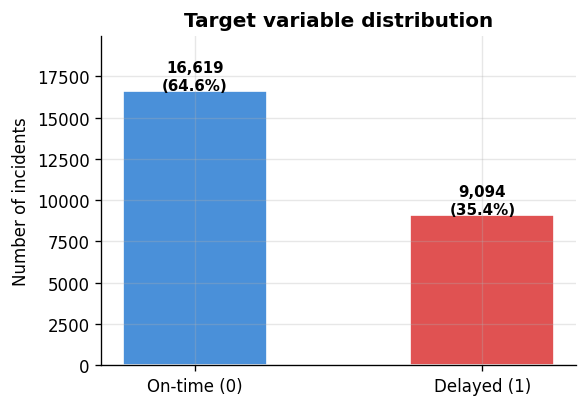

In [ ]:
# Test the target imbalance.

fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df['DELAY_OCCURRED'].value_counts().sort_index()
bars = ax.bar(['On-time (0)', 'Delayed (1)'], counts.values,
              color=['#4A90D9', '#E05252'], width=0.5, edgecolor='white')
ax.set_ylabel('Number of incidents')
ax.set_title('Target variable distribution', fontweight='bold')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 80,
            f'{v:,}\n({v/len(df)*100:.1f}%)',
            ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.show()

In [ ]:
# Test the delay duration states.

delayed_only = df[df['DELAY_OCCURRED'] == 1]['Min Delay']
print("Delay duration — delayed incidents only:")
print(f"  Mean   : {delayed_only.mean():.1f} min")
print(f"  Median : {delayed_only.median():.1f} min")
print(f"  Std    : {delayed_only.std():.1f} min")
print(f"  95th % : {delayed_only.quantile(0.95):.1f} min")
print(f"  Max    : {delayed_only.max():.1f} min")


Delay duration — delayed incidents only:
  Mean   : 7.8 min
  Median : 5.0 min
  Std    : 17.6 min
  95th % : 20.0 min
  Max    : 900.0 min


Because the data has skewed distribution with extreme outliers, we should use RobustScaler instead of StandardScaler when we get to the scaling step.

**Why it matters:**
- StandardScaler scales data based on mean and standard deviation — easily thrown off by outliers
- RobustScaler uses the median and interquartile range (IQR) instead, making it much more resistant to extreme values

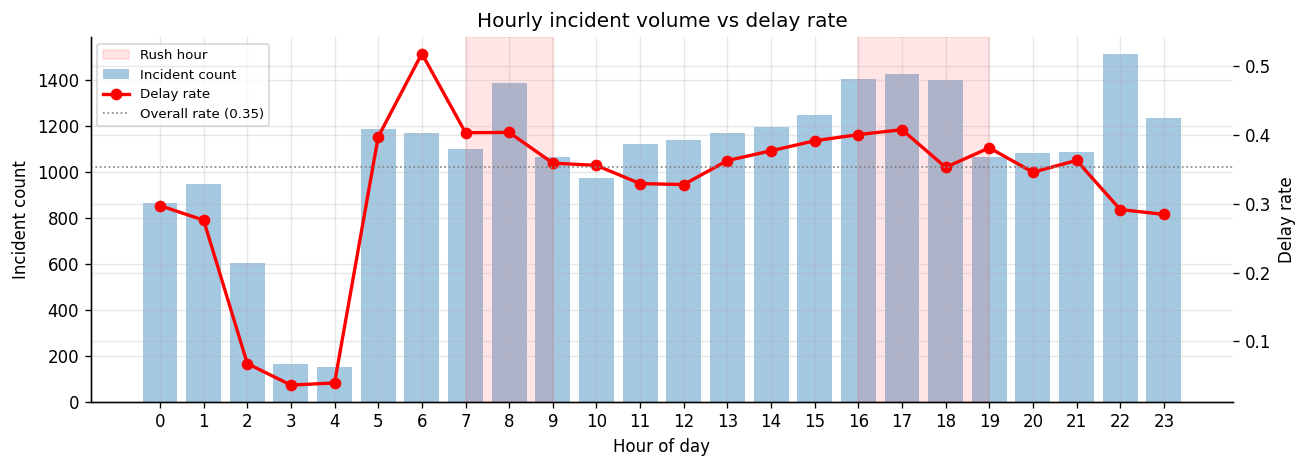

In [ ]:
# Test the influence of rush hours on the delay
df['_hour'] = pd.to_datetime(df['Time'], errors='coerce').dt.hour
hourly = df.groupby('_hour')['DELAY_OCCURRED'].agg(['count', 'mean']).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 4))
ax2 = ax1.twinx()
ax1.bar(hourly['_hour'], hourly['count'], alpha=0.4, label='Incident count')
ax2.plot(hourly['_hour'], hourly['mean'], color='red', marker='o', lw=2, label='Delay rate')

for start, end in [(7, 9), (16, 19)]:
    ax1.axvspan(start, end, alpha=0.1, color='red', label='Rush hour' if start == 7 else '')

ax2.axhline(delay_rate, color='gray', ls=':', lw=1, label=f'Overall rate ({delay_rate:.2f})')
ax1.set_xlabel('Hour of day')
ax1.set_ylabel('Incident count')
ax2.set_ylabel('Delay rate')
ax1.set_title('Hourly incident volume vs delay rate')
ax1.set_xticks(range(0, 24))

lines1, l1 = ax1.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, l1 + l2, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

df.drop(columns=['_hour'], inplace=True)

**Delay rates** are observably higher during rush hours (7–9 AM and 4–7 PM), which encourge the inclusion of time features in the analysis.

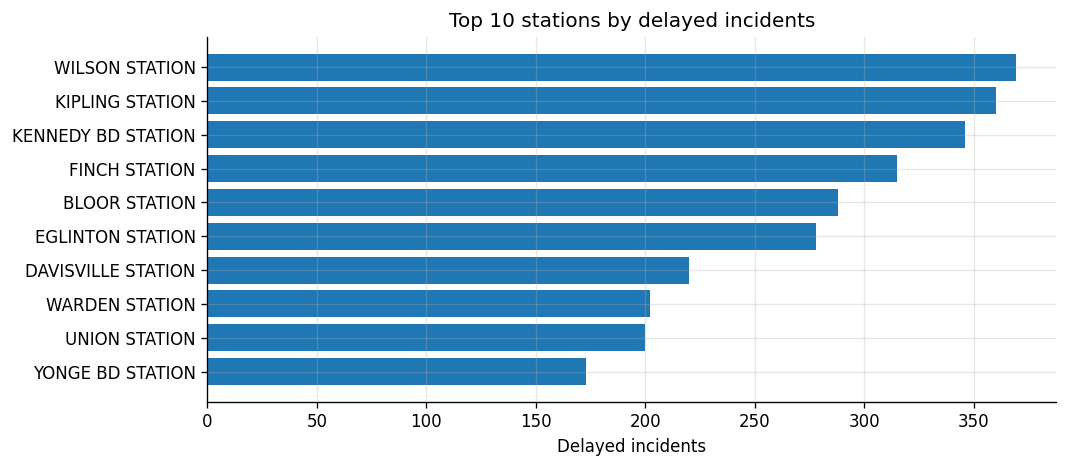

In [ ]:
# Top 10 stations by delayed incidents

top_station_delays = (
    df[df['DELAY_OCCURRED'] == 1]
    .groupby('Station').size()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(top_station_delays.index[::-1], top_station_delays.values[::-1])
ax.set_xlabel('Delayed incidents')
ax.set_title('Top 10 stations by delayed incidents')
plt.tight_layout()
plt.show()


The TTC has 3 real subway lines:
- **YU** → Yonge-University line
- **BD** → Bloor-Danforth line
- **SHP** → Scarborough (formerly SRT)

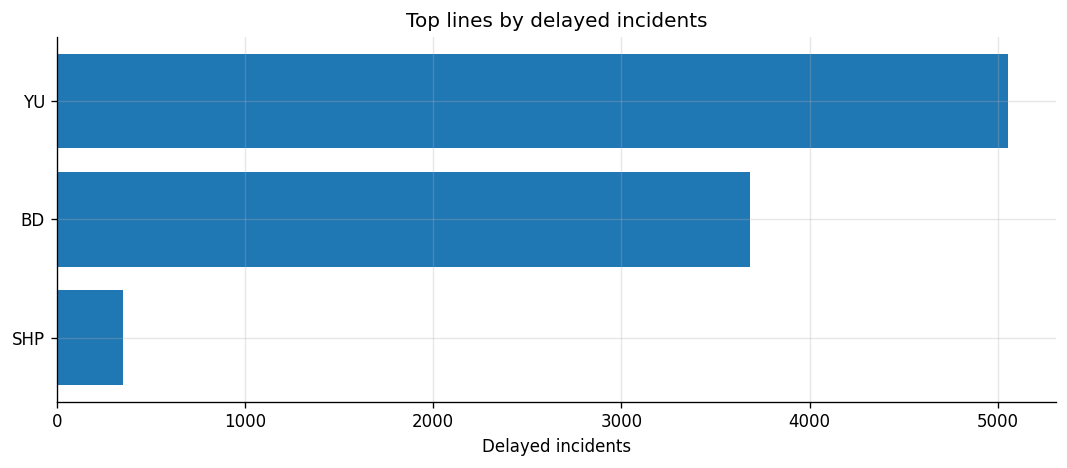

In [ ]:
# Top lines by delayed incidents

line_mapping = {
    'YUS':          'YU',               # old name for Yonge-University-Spadina
    'YU/ BD':       'YU/BD_TRANSFER',
    'YU / BD':      'YU/BD_TRANSFER',
    'YU/BD LINES':  'YU/BD_TRANSFER',
    'YU -BD LINES': 'YU/BD_TRANSFER',
    'YU/BD':        'YU/BD_TRANSFER',
    'YUS/BD':       'YU/BD_TRANSFER',
    'BD/YUS':       'YU/BD_TRANSFER',
    'BD/YU':        'YU/BD_TRANSFER',
    'YU / BD':      'YU/BD_TRANSFER',
    'YUS/ BD':      'YU/BD_TRANSFER',
    'YUS/ BD/ SHP': 'YU/BD_TRANSFER',
    'YU/BD/SHP':    'YU/BD_TRANSFER',
    'SRT':          'SHP',              # rebranded to Scarborough (SHP)
    '29 DUFFERIN':  None,               # bus route, not subway
}

df['Line'] = df['Line'].str.strip().replace(line_mapping)
df = df[df['Line'].notna()]

top_line_delays = (
    df[df['DELAY_OCCURRED'] == 1]
    .groupby('Line').size()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(top_line_delays.index[::-1], top_line_delays.values[::-1])
ax.set_xlabel('Delayed incidents')
ax.set_title('Top lines by delayed incidents')
plt.tight_layout()
plt.show()

* **YU and BD lines dominate delay incidents**, accounting for the vast majority of recorded delays, while SHP remains comparatively minor.
* On the other hand there is only one line scored **zero** delay incident which is **YU/BD_TRANSFER**.
* Thus, line is a strong candidate feature for the prediction model.

## 4. Feature Engineering

Going from 10 raw columns to ~60 features<br>
The most important thing here: rolling features MUST be computed in order, otherwise we leak future data into training which kills generalization

Feature groups:
1. Temporal (hour, rush hour, day-of-week, month — including cyclical encodings)
2. Station (historical delay rate, rolling rate, busyness flags)
3. Line & Direction (per-line rates, bound direction, station × direction)
4. Vehicle (fleet series, per-vehicle history)
5. Incident Code (cause category, frequency, top-code binary flags)
6. Rolling lag (station rolling rate, line rolling rate, gap times)
7. Interaction (rush × weekday, night × weekend, and others)

In [ ]:
def safe_rate(group_col, target_col='DELAY_OCCURRED'):
    """
    fit only on train, then map to everything avoids leaking test delay rates into the encoding.
    """
    rate = df_feat.loc[train_mask, [group_col, target_col]] \
                  .groupby(group_col)[target_col].mean()
    return df_feat[group_col].map(rate).fillna(fill_rate)


def safe_rolling(series, window):
    """
    shift(1) so each row only sees what came before it, not itself
    """
    return (series.shift(1)
                  .rolling(window, min_periods=1)
                  .mean()
                  .fillna(fill_rate))

def safe_encode(col):
    """
    fit encoder on train only, unseen categories in test get -1
    """
    le = LabelEncoder()
    le.fit(df_feat.loc[train_mask, col].fillna('UNKNOWN').astype(str))
    return df_feat[col].fillna('UNKNOWN').astype(str).map(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )

### 4.1 Parse datetime and sort

In [ ]:
df_feat = df.copy()

# Date and Time are separate columns for some reason, combining them
df_feat['date_time'] = pd.to_datetime(
    df_feat['Date'] + ' ' + df_feat['Time'], errors='coerce'
)

n_bad = df_feat['date_time'].isnull().sum()
print(f"Unparseable timestamps: {n_bad}  (will be handled downstream with fillna)")

df_feat = df_feat.sort_values('date_time').reset_index(drop=True)
print(f"Date range : {df_feat['date_time'].min()}  →  {df_feat['date_time'].max()}")
print(f"Total rows : {len(df_feat):,}")

Unparseable timestamps: 0  (will be handled downstream with fillna)
Date range : 2025-01-01 00:27:00  →  2025-12-31 23:23:00
Total rows : 25,645


* **If the model sees future data during training**, it picks up patterns that will happen in the future, this would cause **Data Leakage**, that is why we had to sort the dataset from the precedent to the more recent observations.

### 4.2 Temporal features
*During this section we will create some extra temporal feature based **date_time** feature*

The new created features are:

1.   hour.
2.   hour_sin.
3.   hour_cos.
4.   is_rush_hour.
5.   is_early_morningis_morning.
6.   is_afternoon.
7.   is_evening.
8.   is_night.
9.   day_of_week.
10.  dow_sin.
11.  dow_cos.
12.  is_weekday.
13.  is_weekend.
14.  is_monday.
15.  is_friday.
16.  month.
17.  month_sin.
18.  month_cos.



In [ ]:
df_feat['hour'] = df_feat['date_time'].dt.hour

# Cyclical encoding so that 23:00 and 00:00 aren't being treated as far apart
df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['hour'] / 24)
df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['hour'] / 24)

# Categorize the different day/night hours into features
df_feat['is_rush_hour'] = (
    ((df_feat['hour'] >= 7)  & (df_feat['hour'] <= 9))  |
    ((df_feat['hour'] >= 16) & (df_feat['hour'] <= 19))
).astype(int)

df_feat['is_early_morning'] = ((df_feat['hour'] >= 5)  & (df_feat['hour'] <= 6)).astype(int)
df_feat['is_morning']       = ((df_feat['hour'] >= 7)  & (df_feat['hour'] <= 11)).astype(int)
df_feat['is_afternoon']     = ((df_feat['hour'] >= 12) & (df_feat['hour'] <= 15)).astype(int)
df_feat['is_evening']       = ((df_feat['hour'] >= 16) & (df_feat['hour'] <= 19)).astype(int)
df_feat['is_night']         = ((df_feat['hour'] >= 20) | (df_feat['hour'] <= 4)).astype(int)

print(df_feat[['hour', 'hour_sin', 'hour_cos', 'is_rush_hour']].head(3).to_string())

   hour  hour_sin  hour_cos  is_rush_hour
0     0       0.0       1.0             0
1     0       0.0       1.0             0
2     0       0.0       1.0             0


In [ ]:
# Ordinal for day of week (Mon=0 through Sun=6)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df_feat['day_of_week'] = pd.Categorical(
    df_feat['Day'], categories=day_order, ordered=True
).codes

# Cyclical on top so Sunday and Monday aren't treated as far apart
df_feat['dow_sin'] = np.sin(2 * np.pi * df_feat['day_of_week'] / 7)
df_feat['dow_cos'] = np.cos(2 * np.pi * df_feat['day_of_week'] / 7)

mask = df_feat['Day'].notna()
df_feat['is_weekday'] = 0
df_feat['is_weekend'] = 0
df_feat.loc[mask, 'is_weekday'] = (~df_feat.loc[mask, 'Day'].isin(['Saturday','Sunday'])).astype(int)
df_feat.loc[mask, 'is_weekend'] = ( df_feat.loc[mask, 'Day'].isin(['Saturday','Sunday'])).astype(int)

df_feat['is_monday'] = (df_feat['Day'] == 'Monday').astype(int)
df_feat['is_friday'] = (df_feat['Day'] == 'Friday').astype(int)

In [ ]:
df_feat['month']     = df_feat['date_time'].dt.month
df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)

print(f"Months covered: {sorted(df_feat['month'].unique())}")

Months covered: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


### 4.3 Station features

*During this section we will create some extra temporal feature based **station** feature*


*   Note that we those station names may have errors due to inaccurate import process, that is way we need first to clean that feature.

The new created features are:


19.   station_encoded.
20.   station_delay_rate.
21.   station_incident_count.
22.   is_top10_station.




In [ ]:
import re

valid_stations = [
    'BATHURST', 'BAY', 'BAYVIEW', 'BESSARION', 'BLOOR-YONGE', 'BLOOR',
    'BROADVIEW', 'CASTLE FRANK', 'CHESTER', 'CHRISTIE', 'COLLEGE',
    'COXWELL', 'DAVISVILLE', 'DON MILLS', 'DONLANDS', 'DOWNSVIEW PARK',
    'DUFFERIN', 'DUNDAS WEST', 'DUNDAS', 'DUPONT', 'EGLINTON WEST',
    'EGLINTON', 'FINCH WEST', 'FINCH', 'GLENCAIRN', 'GREENWOOD',
    'HIGH PARK', 'ISLINGTON', 'JANE', 'KEELE', 'KENNEDY', 'KING',
    'KIPLING', 'LANSDOWNE', 'LAWRENCE WEST', 'LAWRENCE', 'LEASIDE',
    'LESLIE', 'MAIN', 'MUSEUM', 'NORTH YORK CENTRE', 'OLD MILL',
    'OSGOODE', 'OSSINGTON', 'PAPE', 'PIONEER VILLAGE', 'QUEEN QUAY',
    "QUEEN'S PARK", 'QUEEN', 'ROSEDALE', 'ROYAL YORK', 'RUNNYMEDE',
    'SCARBOROUGH TOWN CENTRE', 'SHEPPARD WEST', 'SHEPPARD-YONGE',
    'SHEPPARD', 'SHERBOURNE', 'SPADINA', 'ST ANDREW', 'ST CLAIR WEST',
    'ST CLAIR', 'ST GEORGE', 'ST PATRICK', 'SUMMERHILL', 'TMU',
    'UNION', 'VICTORIA PARK', 'VMC', 'WARDEN', 'WELLESLEY',
    'WILSON', 'WOODBINE', 'YORK MILLS', 'YORK UNIVERSITY', 'YORKDALE',
]

pattern = '|'.join(re.escape(s) for s in valid_stations)

matches = df_feat['Station'].str.strip().str.upper().str.extract(f'({pattern})', expand=False)
df_feat['Station'] = matches
df_feat = df_feat[df_feat['Station'].notna()]

print(f"Unique stations after cleaning: {df_feat['Station'].nunique()}")
print(sorted(df_feat['Station'].unique()))

Unique stations after cleaning: 72
['BATHURST', 'BAY', 'BESSARION', 'BLOOR', 'BROADVIEW', 'CASTLE FRANK', 'CHESTER', 'CHRISTIE', 'COLLEGE', 'COXWELL', 'DAVISVILLE', 'DON MILLS', 'DONLANDS', 'DOWNSVIEW PARK', 'DUFFERIN', 'DUNDAS', 'DUNDAS WEST', 'DUPONT', 'EGLINTON', 'EGLINTON WEST', 'FINCH', 'FINCH WEST', 'GLENCAIRN', 'GREENWOOD', 'HIGH PARK', 'ISLINGTON', 'JANE', 'KEELE', 'KENNEDY', 'KING', 'KIPLING', 'LANSDOWNE', 'LAWRENCE', 'LAWRENCE WEST', 'LEASIDE', 'LESLIE', 'MAIN', 'MUSEUM', 'NORTH YORK CENTRE', 'OLD MILL', 'OSGOODE', 'OSSINGTON', 'PAPE', 'PIONEER VILLAGE', 'QUEEN', 'QUEEN QUAY', "QUEEN'S PARK", 'ROSEDALE', 'ROYAL YORK', 'RUNNYMEDE', 'SHEPPARD', 'SHEPPARD WEST', 'SHEPPARD-YONGE', 'SHERBOURNE', 'SPADINA', 'ST ANDREW', 'ST CLAIR', 'ST CLAIR WEST', 'ST GEORGE', 'ST PATRICK', 'SUMMERHILL', 'TMU', 'UNION', 'VICTORIA PARK', 'VMC', 'WARDEN', 'WELLESLEY', 'WILSON', 'WOODBINE', 'YORK MILLS', 'YORK UNIVERSITY', 'YORKDALE']


In [ ]:
original_len = len(df)
cleaned_len = len(df_feat)
dropped = original_len - cleaned_len

print(f"Original rows : {original_len:,}")
print(f"After cleaning: {cleaned_len:,}")
print(f"Dropped       : {dropped:,} ({dropped/original_len*100:.1f}%)")

print("\nDelay proportion before cleaning:")
print(df['DELAY_OCCURRED'].value_counts(normalize=True).rename({0: 'no delay', 1: 'delay'}))

print("\nDelay proportion after cleaning:")
print(df_feat['DELAY_OCCURRED'].value_counts(normalize=True).rename({0: 'no delay', 1: 'delay'}))

Original rows : 25,645
After cleaning: 24,027
Dropped       : 1,618 (6.3%)

Delay proportion before cleaning:
DELAY_OCCURRED
no delay    0.645428
delay       0.354572
Name: proportion, dtype: float64

Delay proportion after cleaning:
DELAY_OCCURRED
no delay    0.636617
delay       0.363383
Name: proportion, dtype: float64



*   The **Station** column was a mix of actual station names, street addresses, maintenance locations, emergency exit and others.
*   We defined a whitelist of the 74 TTC station names and used regex to extract the first match from each entry.
*   Anything that didn't contain a known station name was dropped.

We lost 1,618 rows (6.3%), but these were mostly junk entries that wouldn't have added signal anyway, Also the delay rate barely moved (35.5% → 36.3%), so the drop didn't skew the class balance.

## Train / Test Split

**Why chronological and not random?**

Rolling features for a given incident are computed from earlier incidents.
A random split would put some of those earlier incidents in the test set,
meaning training examples would implicitly contain future information.
That is data leakage.

Chronological split (first 80% train, last 20% test) correctly simulates
deployment: the model is trained on historical data and predicts on future
incidents it has never seen.

In [ ]:
df_feat = df_feat.reset_index(drop=True)

split_idx = int(len(df_feat) * 0.80)
train_mask = np.arange(len(df_feat)) < split_idx
fill_rate = df_feat['DELAY_OCCURRED'].iloc[:split_idx].mean()
y_train = df_feat['DELAY_OCCURRED'].iloc[:split_idx]
y_test = df_feat['DELAY_OCCURRED'].iloc[split_idx:]

print(f"Train rows : {split_idx:,}  |  Test rows : {len(df_feat)-split_idx:,}")
print(f"Delayed in train : {y_train.mean()*100:.1f}%")
print(f"Delayed in test  : {y_test.mean()*100:.1f}%")
print(f"fill_rate  : {fill_rate:.4f}")

Train rows : 19,221  |  Test rows : 4,806
Delayed in train : 36.0%
Delayed in test  : 37.8%
fill_rate  : 0.3598


In [ ]:
# Use Label Encoding For Station Name

df_feat['station_encoded'] = safe_encode('Station')
print(f"The Total Number of Unique Stations Is: {df_feat['Station'].nunique()}")

The Total Number of Unique Stations Is: 72


* Each station is assigned a single number representing the **fraction of its incidents that resulted in a delay**.
* this directly encodes the station's **Historical Prior Probability** of causing a delay, making it a strong prior for the prediction target `IS_DELAYED`.


In [ ]:
# Get the delay rate per station, this would measure how likely a station is to have a delay

df_feat['station_delay_rate'] = safe_rate('Station')

print("top 5 worst stations by delay rate:")
print(df_feat['station_delay_rate'].sort_values(ascending=False).head(5).round(3).to_string())

top 5 worst stations by delay rate:
17       0.546
3202     0.546
3189     0.546
3165     0.546
20081    0.546


In [ ]:
# Get top 10 stations in which most observations occured

df_feat['station_incident_count'] = df_feat['Station'].map(df_feat.loc[train_mask, 'Station'].value_counts()).fillna(1)
df_feat['is_top10_station'] = df_feat['Station'].isin(df_feat.loc[train_mask, 'Station'].value_counts().head(10).index).astype(int)

print(f"Top 10 stations: {list(df_feat['is_top10_station'])}")

Top 10 stations: [0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1

### 4.4 Line features

The new created features are:

23. line_encoded
24. is_line_YU
25. is_line_BD
26. is_line_SHP
27. is_interlining
28. line_delay_rate


In [ ]:
df_feat['line_encoded'] = safe_encode('Line')

df_feat['is_line_YU']  = (df_feat['Line'] == 'YU').astype(int)
df_feat['is_line_BD']  = (df_feat['Line'] == 'BD').astype(int)
df_feat['is_line_SHP'] = (df_feat['Line'] == 'SHP').astype(int)
df_feat['is_interlining'] = (df_feat['Line'] == 'YU/BD_TRANSFER').astype(int)

df_feat['line_delay_rate'] = safe_rate('Line')

### 4.5 Direction features

The new created features are:

29. bound_encoded
30. is_northbound
31. is_southbound
32. is_eastbound
33. is_westbound
34. is_bidirectional
35. station_direction
36. station_direction_encoded

In [ ]:
df_feat['bound_is_missing'] = df_feat['Bound'].isna().astype(int)
print(f"Rows with missing Bound: {df_feat['bound_is_missing'].sum():,} ({df_feat['bound_is_missing'].mean()*100:.1f}%)")

# most TTC stations serve only one direction per line
# build a lookup from rows that have a Bound value and use it to fill the rest
bound_lookup = (
    df_feat[train_mask & df_feat['Bound'].notna()]
    .groupby(['Station','Line'])['Bound']
    .agg(lambda x: x.mode()[0])
)
df_feat['Bound'] = df_feat.apply(
    lambda r: r['Bound'] if pd.notna(r['Bound'])
              else bound_lookup.get((r['Station'], r['Line']), 'UNKNOWN'), axis=1)

still_missing = (df_feat['Bound'] == 'UNKNOWN').sum()
recovered = df_feat['bound_is_missing'].sum() - still_missing
print(f"Recovered via lookup: {recovered:,}")
print(f"Still unknown: {still_missing:,}")

Rows with missing Bound: 8,439 (35.1%)
Recovered via lookup: 8,399
Still unknown: 40


In [ ]:
df_feat['bound_encoded'] = safe_encode('Bound')

df_feat['is_northbound']    = (df_feat['Bound'] == 'N').astype(int)
df_feat['is_southbound']    = (df_feat['Bound'] == 'S').astype(int)
df_feat['is_eastbound']     = (df_feat['Bound'] == 'E').astype(int)
df_feat['is_westbound']     = (df_feat['Bound'] == 'W').astype(int)
df_feat['is_bidirectional'] = (df_feat['Bound'] == 'B').astype(int)

# station + direction give the model since of platform-level patterns
df_feat['station_direction'] = df_feat['Station'].astype(str) + '_' + df_feat['Bound'].astype(str)
df_feat['station_direction_encoded'] = safe_encode('station_direction')


### 4.6 Incident code features

Features that were created are:

41. code_encoded
42. code_cat_MECHANICAL
43. code_cat_SIGNAL
44. code_cat_TRACK
45. code_cat_PASSENGER
46. code_cat_ELECTRICAL
47. code_cat_OTHER
48. code_cat_UNKNOWN
49. code_frequency

In [ ]:
# The first two letters of the code indicate cause type (MU = mechanical etc.)
# grouping these since there are too many individual codes to one-hot directly
prefix_map = {'MU': 'MECHANICAL', 'SU': 'SIGNAL', 'TU': 'TRACK', 'PU': 'PASSENGER', 'EU': 'ELECTRICAL'}

df_feat['code_category'] = df_feat['Code'].astype(str).str.upper().str[:2].map(prefix_map).fillna('OTHER')
df_feat.loc[df_feat['Code'].isna() | (df_feat['Code'].astype(str) == '0'), 'code_category'] = 'UNKNOWN'

for cat, cnt in df_feat['code_category'].value_counts().items():
    dr = df_feat.loc[df_feat['code_category'] == cat, 'DELAY_OCCURRED'].mean()
    print(f"{cat}: {cnt:,} incidents, delay rate = {dr:.3f}")

MECHANICAL: 9,691 incidents, delay rate = 0.318
SIGNAL: 6,223 incidents, delay rate = 0.345
PASSENGER: 3,954 incidents, delay rate = 0.424
TRACK: 2,739 incidents, delay rate = 0.366
ELECTRICAL: 1,418 incidents, delay rate = 0.583
OTHER: 2 incidents, delay rate = 0.000


In [ ]:
# Encode raw code and one-hot the category
df_feat['code_encoded'] = safe_encode('Code')

# One-hot encode cause category — no ordinal assumption between categories
code_dummies = pd.get_dummies(df_feat['code_category'], prefix='code_cat')
df_feat = pd.concat([df_feat, code_dummies], axis=1)
df_feat.drop(columns=['code_category'], inplace=True)

# Code frequency: rare codes are harder to predict (fewer examples to learn from)
code_freq = df_feat.loc[train_mask, 'Code'].value_counts(normalize=True)
df_feat['code_frequency'] = df_feat['Code'].map(code_freq).fillna(0)

# Binary flag for each of the 10 most common codes.
# These dominate incident volume and each deserves its own feature rather
# than being compressed into the single frequency score.
top10_codes = df_feat.loc[train_mask, 'Code'].value_counts().head(10).index
for c in top10_codes:
    df_feat[f'code_{c}'] = (df_feat['Code'] == c).astype(int)

print(f"Code features added: {len(code_dummies.columns)} one-hot + 1 frequency + 10 binary flags")

Code features added: 6 one-hot + 1 frequency + 10 binary flags


### 4.7 Rolling lag features

Features that were included:

50. station_rolling_delay_rate
51. line_rolling_delay_rate
52. station_time_since_last
53. line_time_since_last
54. hourly_line_delays

In [ ]:
# these are the most important features in the whole pipeline
# station_rolling_delay_rate = fraction of last 50 incidents at this station that were delayed
# if a station is having a bad run it's likely to keep having delays

df_feat['station_rolling_delay_rate'] = df_feat.groupby('Station')['DELAY_OCCURRED'].transform(lambda x: safe_rolling(x, 50))
df_feat['line_rolling_delay_rate']    = df_feat.groupby('Line')['DELAY_OCCURRED'].transform(lambda x: safe_rolling(x, 100))
df_feat['hourly_line_delays'] = df_feat.groupby(['Line','hour'])['DELAY_OCCURRED'].transform(lambda x: safe_rolling(x, 24))
df_feat['station_time_since_last'] = df_feat.groupby('Station')['date_time'].transform(lambda x: x.diff().dt.total_seconds().div(3600).fillna(24))
df_feat['line_time_since_last'] = df_feat.groupby('Line')['date_time'].transform(lambda x: x.diff().dt.total_seconds().div(3600).fillna(24))

### 4.8 Interaction features

The features that were created are:

55. rush_hour_weekday
56. night_weekend

In [ ]:
# two interaction terms that seemed obviously meaningful
# rush_hour_weekday = highest risk combo
# night_weekend = lowest risk combo
# tree models learn these anyway but helps LR

# Peak hour on a weekday = the single highest-risk operating window
df_feat['rush_hour_weekday'] = df_feat['is_rush_hour'] * df_feat['is_weekday']

# Late night on a weekend = minimal service, lowest overall risk
df_feat['night_weekend'] = df_feat['is_night'] * df_feat['is_weekend']

print(f"Total columns in df_feat after all feature engineering: {df_feat.shape[1]}")

Total columns in df_feat after all feature engineering: 76


## 5. Select Features

Drop everything that is:
- A raw string identifier already encoded above
- The target variable itself (`DELAY_OCCURRED`)
- A direct leakage source (`Min Delay`, `Min Gap` — these ARE the delay)
- Vehicle feature because it is mostly empty and introduces correlation with the target.
- bound_is_missing because it only highlight 40 rows.
- An intermediate construction column (`station_direction`, `date_time`)

In [ ]:
exclude = {
    '_id', 'Date', 'Time', 'Day', 'Station', 'Code', 'Bound',
    'Line', 'Vehicle', 'Min Delay', 'Min Gap',
    'DELAY_OCCURRED', 'date_time', 'station_direction',
    'Vehicle', 'bound_is_missing'
}

feature_cols = []
for col in df_feat.columns:
    if col in exclude:
        continue
    s = df_feat.iloc[:split_idx][col]
    if pd.api.types.is_numeric_dtype(s) and s.nunique() > 1:
        feature_cols.append(col)
    elif pd.api.types.is_categorical_dtype(s):
        feature_cols.append(col)
    elif pd.api.types.is_bool_dtype(s):
        df_feat[col] = s.astype(int)
        feature_cols.append(col)

X = df_feat[feature_cols]
X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

print(f"Selected {len(feature_cols)} features")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")

Selected 61 features
X_train: (19221, 61)  |  X_test: (4806, 61)


## 6. Scale Numeric Features

**RobustScaler** is chosen over StandardScaler
because `Min Delay` values have outliers.
StandardScaler lets those extremes distort the mean and std used for scaling, while for RobustScaler it eliminate their influence because it uses median.

**Important:** the scaler is fitted on training data only, then applied to
test data — fitting on the full dataset would leak test-set statistics.

In [ ]:
cat_cols     = [c for c in feature_cols if df_feat[c].dtype.name == 'category']
numeric_cols = [c for c in feature_cols
                if c not in cat_cols
                and df_feat[c].dtype in ['int64','float64','int32','float32']]

scaler = RobustScaler(quantile_range=(5, 95))

X_train_num = X_train[numeric_cols].copy()
X_test_num  = X_test[numeric_cols].copy()

# Fit on train only, apply the same transform to test
X_train_num[numeric_cols] = scaler.fit_transform(X_train_num)
X_test_num[numeric_cols]  = scaler.transform(X_test_num)

# A handful of rolling features are NaN for the very first incident in each group
# (nothing to roll over yet).  Fill with the overall training delay rate —
# a conservative, uninformative estimate that avoids leaking any test signal.
fill_rate = y_train.mean()
for col in ['line_rolling_delay_rate', 'hourly_line_delays']:
    if col in X_train_num.columns:
        X_train_num[col] = X_train_num[col].fillna(fill_rate)
        X_test_num[col]  = X_test_num[col].fillna(fill_rate)

print(f"Scaled {len(numeric_cols)} numeric features")
print(f"NaN fill value : {fill_rate:.4f}  (= overall training delay rate)")
print(f"NaNs remaining in train: {X_train_num.isnull().sum().sum()}")
print(f"NaNs remaining in test : {X_test_num.isnull().sum().sum()}")

Scaled 54 numeric features
NaN fill value : 0.3598  (= overall training delay rate)
NaNs remaining in train: 0
NaNs remaining in test : 0


## 7. Handle Class Imbalance

The delayed class is only ~35 % of all incidents.
A naive model can reach ~65 % accuracy by always predicting "on-time" —
which is completely useless for our purpose.

We use **class weighting**: the loss function treats each delayed incident
as if it were ~1.85 on-time incidents.  This shifts the decision boundary
toward catching delays at the cost of more false alarms — the right trade-off
when missing a delay is operationally far worse than a false alarm.

Different models accept the weight differently:
- `GradientBoosting` → `sample_weight` array at `fit()` time
- `XGBoost`          → `scale_pos_weight` constructor parameter
- All others         → `class_weight='balanced'` constructor parameter

In [ ]:
# The ratio is: (number of on-time) / (number of delayed)
delay_ratio = (y_train == 0).sum() / (y_train == 1).sum()

# Per-sample weight array — used only for GradientBoosting
sample_weights = np.where(y_train == 1, delay_ratio, 1.0)

print(f"On-time  count : {(y_train==0).sum():,}")
print(f"Delayed  count : {(y_train==1).sum():,}")
print(f"Delay class weight : {delay_ratio:.4f}")
print(f"\nEach delayed incident counts as {delay_ratio:.2f}× a normal incident in the loss.")

On-time  count : 12,306
Delayed  count : 6,915
Delay class weight : 1.7796

Each delayed incident counts as 1.78× a normal incident in the loss.


## 8. Shared Evaluation Utilities

All metric logic lives here so every model section uses identical evaluation.

**Metric definitions:**
| Metric | Formula | What it tells us |
|--------|---------|-----------------|
| Recall (Sensitivity) | TP / (TP+FN) | Of all real delays, how many did we catch? **Hard target ≥ 0.80** |
| Precision (PPV) | TP / (TP+FP) | Of all delay alerts, how many were real? |
| F1 Score | harmonic mean(P, R) | Primary ranking metric — balances precision & recall |
| PR-AUC | area under PR curve | Threshold-independent summary of model quality |
| Specificity | TN / (TN+FP) | Of all real on-times, how many did we correctly label? |
| NPV | TN / (TN+FN) | Of all "no-delay" predictions, how many were truly on-time? |

In [ ]:
def compute_all_metrics(y_true, y_pred, y_prob):
    """Return a dict of every evaluation metric for one model at one threshold."""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'recall'      : recall_score(y_true, y_pred,    zero_division=0),
        'precision'   : precision_score(y_true, y_pred, zero_division=0),
        'f1'          : f1_score(y_true, y_pred,        zero_division=0),
        'pr_auc'      : average_precision_score(y_true, y_prob),
        'roc_auc'     : roc_auc_score(y_true, y_prob),
        'specificity' : tn / (tn + fp) if (tn + fp) > 0 else 0,
        'npv'         : tn / (tn + fn) if (tn + fn) > 0 else 0,
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
        'cm': cm,
    }

In [ ]:
def print_metrics(name, m, threshold=0.5):
    """Pretty-print a single model's full metric set."""
    status = '✓ PASS' if m['recall'] >= 0.80 else '✗ BELOW TARGET'
    print(f"{'─'*62}")
    print(f"  {name}   (threshold = {threshold:.3f})")
    print(f"{'─'*62}")
    print(f"  Recall (Sensitivity) : {m['recall']:.4f}   {status}")
    print(f"  Precision (PPV)      : {m['precision']:.4f}")
    print(f"  F1 Score             : {m['f1']:.4f}")
    print(f"  PR-AUC               : {m['pr_auc']:.4f}")
    print(f"  ROC-AUC              : {m['roc_auc']:.4f}")
    print(f"  Specificity          : {m['specificity']:.4f}")
    print(f"  NPV                  : {m['npv']:.4f}")
    print(f"  Confusion matrix:")
    print(f"             Predicted On-time  Predicted Delayed")
    print(f"  Actual On-time   {m['tn']:10,}      {m['fp']:10,}")
    print(f"  Actual Delayed   {m['fn']:10,}      {m['tp']:10,}")

In [ ]:
def tune_model(estimator, param_dist, n_iter=30, fit_kw=None):
    """
    Run RandomizedSearchCV with 3-fold TimeSeriesSplit.
    """
    rs = RandomizedSearchCV(
        estimator,
        param_distributions=param_dist,
        n_iter=n_iter,
        cv=TimeSeriesSplit(n_splits=3),
        scoring="f1",
        n_jobs=-1,
        random_state=42,
        verbose=0,
    )
    rs.fit(X_train_num, y_train, **(fit_kw or {}))
    best_idx = rs.best_index_
    print(f"  Best CV F1 : {rs.cv_results_['mean_test_score'][best_idx]:.4f}")
    print(f"  Best params: {rs.best_params_}")
    return rs

In [ ]:
# ── Storage containers — populated as each model is trained ──────────────────
metrics_before = {}   # performance with default hyperparameters
metrics_after = {}   # performance after RandomizedSearchCV tuning
y_probs_after = {}   # predicted probabilities on test set (all 7 models)
y_preds_after = {}   # predicted labels at default threshold 0.5
y_preds_opt = {}   # predicted labels at optimized threshold
opt_thresholds = {}   # the per-model optimized threshold (Section 11)
feature_imps = {}   # feature importances for all 6 tree/linear
final_models   = {} # stores the final version of each model after tunning to serve optimization purposes

# model tiers:
# tier 1 -> real candidates: GB, XGB, LightGBM, RF, ET
# tier 2 -> linear baseline: LR (expected floor for real models)
# tier 3 -> negative control: KNN (expected to fail, validates model choice)

MODEL_ORDER = [
    'Logistic Regression',
    'Gradient Boosting',
    'XGBoost',
    'LightGBM',
    'Random Forest',
    'Extra Trees',
    'KNN',
]

## 9. Model Training

For each model:
1. **Baseline** — train with sensible defaults → record initial performance
2. **Tune** — `RandomizedSearchCV` with 3-fold `TimeSeriesSplit` → best params
3. **Final fit** — refit on the full training set with the best params
4. **Evaluate** — report all metrics on the held-out test set

---

### 9.1 Logistic Regression — Explicit Baseline

**Why LR is the baseline:**  
Logistic Regression can only learn linear decision boundaries.


Every other model we build should beat LR by a meaningful margin.
If it doesn't, the added complexity is not justified.

LR also produces interpretable coefficients that directly show which features
raise or lower delay risk which is useful for communicating results to TTC operations
staff who are not data scientists.

In [ ]:
lr_base = LogisticRegression(
    C=0.1,                    # mild L2 regularisation to prevent overfitting
    penalty='l2',
    solver='liblinear',       # reliable and fast for this dataset size
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
)
lr_base.fit(X_train_num, y_train)

y_pred_lr_base = lr_base.predict(X_test_num)
y_prob_lr_base = lr_base.predict_proba(X_test_num)[:, 1]

m = compute_all_metrics(y_test, y_pred_lr_base, y_prob_lr_base)
print_metrics("Logistic Regression — BASELINE", m)
metrics_before['Logistic Regression'] = m

──────────────────────────────────────────────────────────────
  Logistic Regression — BASELINE   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.8739   ✓ PASS
  Precision (PPV)      : 0.5690
  F1 Score             : 0.6893
  PR-AUC               : 0.6569
  ROC-AUC              : 0.8043
  Specificity          : 0.5980
  NPV                  : 0.8865
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        1,788           1,202
  Actual Delayed          229           1,587


In [ ]:
lr_params = {
    'C'           : [0.001, 0.01, 0.1, 0.5, 1.0],
    'penalty'     : ['l1', 'l2'],
    'solver'      : ['liblinear', 'saga'],
    'max_iter'    : [500, 1000, 2000],
    'class_weight': ['balanced'],
}
lr_rs = tune_model(LogisticRegression(random_state=42), lr_params, n_iter=30)

  Best CV F1 : 0.6598
  Best params: {'solver': 'saga', 'penalty': 'l1', 'max_iter': 2000, 'class_weight': 'balanced', 'C': 0.1}


In [ ]:
final_lr = LogisticRegression(**lr_rs.best_params_, random_state=42)
final_lr.fit(X_train_num, y_train)
final_models['Logistic Regression'] = final_lr

y_prob_lr = final_lr.predict_proba(X_test_num)[:, 1]
y_pred_lr = final_lr.predict(X_test_num)

m = compute_all_metrics(y_test, y_pred_lr, y_prob_lr)
print_metrics("Logistic Regression — AFTER TUNING", m)
metrics_after['Logistic Regression'] = m
y_probs_after['Logistic Regression'] = y_prob_lr
y_preds_after['Logistic Regression'] = y_pred_lr

# Store ALL feature importances (absolute coefficient value per feature).
# unified importance chart when the top-15 cross-model features weren't all
# in LR's personal top-20.  Storing all features prevents this crash.
feature_imps['Logistic Regression'] = pd.Series(
    np.abs(final_lr.coef_[0]), index=X_train_num.columns
)

──────────────────────────────────────────────────────────────
  Logistic Regression — AFTER TUNING   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.8491   ✓ PASS
  Precision (PPV)      : 0.5630
  F1 Score             : 0.6771
  PR-AUC               : 0.6438
  ROC-AUC              : 0.7874
  Specificity          : 0.5997
  NPV                  : 0.8674
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        1,793           1,197
  Actual Delayed          274           1,542


### 9.2 Gradient Boosting

Builds trees **sequentially** where each new tree corrects the residuals of
the previous ones.  Great at capturing non-linear interactions; slower
to train than parallel methods like Random Forest.

Does not accept `class_weight`.  We pass `sample_weight` at fit time instead.

In [ ]:
gb_base = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    min_samples_leaf=5, subsample=0.8, random_state=42,
)
gb_base.fit(X_train_num, y_train, sample_weight=sample_weights)

y_pred_gb_base = gb_base.predict(X_test_num)
y_prob_gb_base = gb_base.predict_proba(X_test_num)[:, 1]
m = compute_all_metrics(y_test, y_pred_gb_base, y_prob_gb_base)
print_metrics("Gradient Boosting — BASELINE", m)
metrics_before['Gradient Boosting'] = m

──────────────────────────────────────────────────────────────
  Gradient Boosting — BASELINE   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.8744   ✓ PASS
  Precision (PPV)      : 0.6357
  F1 Score             : 0.7362
  PR-AUC               : 0.7904
  ROC-AUC              : 0.8752
  Specificity          : 0.6957
  NPV                  : 0.9012
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        2,080             910
  Actual Delayed          228           1,588


In [ ]:
gb_params = {
    'n_estimators'    : [50, 100, 150, 200],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.15],
    'max_depth'       : [3, 4, 5, 6],
    'min_samples_leaf': [2, 5, 10],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
}
gb_rs = tune_model(
    GradientBoostingClassifier(random_state=42), gb_params, n_iter=50,
    fit_kw={'sample_weight': sample_weights},
)

  Best CV F1 : 0.7260
  Best params: {'subsample': 0.8, 'n_estimators': 50, 'min_samples_leaf': 5, 'max_depth': 5, 'learning_rate': 0.1}


In [ ]:
final_gb = GradientBoostingClassifier(**gb_rs.best_params_, random_state=42)
final_gb.fit(X_train_num, y_train, sample_weight=sample_weights)
final_models['Gradient Boosting'] = final_gb

y_prob_gb = final_gb.predict_proba(X_test_num)[:, 1]
y_pred_gb = final_gb.predict(X_test_num)
m = compute_all_metrics(y_test, y_pred_gb, y_prob_gb)
print_metrics("Gradient Boosting — AFTER TUNING", m)
metrics_after['Gradient Boosting'] = m
y_probs_after['Gradient Boosting'] = y_prob_gb
y_preds_after['Gradient Boosting'] = y_pred_gb
feature_imps['Gradient Boosting'] = pd.Series(
    final_gb.feature_importances_, index=X_train_num.columns
)
print("\nTop 10 features — Gradient Boosting:")
print(feature_imps['Gradient Boosting'].sort_values(ascending=False).head(10).round(4).to_string())

──────────────────────────────────────────────────────────────
  Gradient Boosting — AFTER TUNING   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.8651   ✓ PASS
  Precision (PPV)      : 0.6579
  F1 Score             : 0.7474
  PR-AUC               : 0.8030
  ROC-AUC              : 0.8815
  Specificity          : 0.7268
  NPV                  : 0.8987
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        2,173             817
  Actual Delayed          245           1,571

Top 10 features — Gradient Boosting:
code_frequency             0.4685
code_encoded               0.3227
station_delay_rate         0.0291
hour                       0.0162
hour_sin                   0.0149
hourly_line_delays         0.0148
code_MUPAA                 0.0118
station_incident_count     0.0110
station_time_since_last    0.0088
is_bidirectional           0.0075


### 9.3 XGBoost

same idea as GB but with L1/L2 regularization and column subsampling

`scale_pos_weight` directly rescales the loss function — equivalent to
class weighting but baked into the gradient computation.

In [ ]:
scale_pos_w = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_w,
    random_state=42, verbosity=0, eval_metric='logloss',
)
xgb_base.fit(X_train_num, y_train)

y_pred_xgb_base = xgb_base.predict(X_test_num)
y_prob_xgb_base = xgb_base.predict_proba(X_test_num)[:, 1]
m = compute_all_metrics(y_test, y_pred_xgb_base, y_prob_xgb_base)
print_metrics("XGBoost — BASELINE", m)
metrics_before['XGBoost'] = m

──────────────────────────────────────────────────────────────
  XGBoost — BASELINE   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.8926   ✓ PASS
  Precision (PPV)      : 0.6273
  F1 Score             : 0.7368
  PR-AUC               : 0.7733
  ROC-AUC              : 0.8717
  Specificity          : 0.6779
  NPV                  : 0.9122
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        2,027             963
  Actual Delayed          195           1,621


In [ ]:
xgb_params = {
    'n_estimators'    : [50, 100, 150, 200, 250],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth'       : [3, 4, 5, 6, 7],
    'min_child_weight': [1, 3, 5, 7, 10],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma'           : [0, 0.1, 0.2, 0.3],
    'reg_alpha'       : [0, 0.01, 0.1, 1],
    'reg_lambda'      : [0, 0.01, 0.1, 1],
}
xgb_rs = tune_model(
    XGBClassifier(scale_pos_weight=scale_pos_w, random_state=42,
                  verbosity=0, eval_metric='logloss'),
    xgb_params, n_iter=50,
)

  Best CV F1 : 0.7231
  Best params: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.9}


In [ ]:
final_xgb = XGBClassifier(
    **xgb_rs.best_params_,
    scale_pos_weight=scale_pos_w,
    random_state=42, verbosity=0, eval_metric='logloss',
)
final_xgb.fit(X_train_num, y_train)
final_models['XGBoost'] = final_xgb

y_prob_xgb = final_xgb.predict_proba(X_test_num)[:, 1]
y_pred_xgb = final_xgb.predict(X_test_num)
m = compute_all_metrics(y_test, y_pred_xgb, y_prob_xgb)
print_metrics("XGBoost — AFTER TUNING", m)
metrics_after['XGBoost'] = m
y_probs_after['XGBoost'] = y_prob_xgb
y_preds_after['XGBoost'] = y_pred_xgb
feature_imps['XGBoost'] = pd.Series(
    final_xgb.feature_importances_, index=X_train_num.columns
)
print("\nTop 10 features — XGBoost:")
print(feature_imps['XGBoost'].sort_values(ascending=False).head(10).round(4).to_string())

──────────────────────────────────────────────────────────────
  XGBoost — AFTER TUNING   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.8221   ✓ PASS
  Precision (PPV)      : 0.6743
  F1 Score             : 0.7409
  PR-AUC               : 0.8053
  ROC-AUC              : 0.8809
  Specificity          : 0.7589
  NPV                  : 0.8754
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        2,269             721
  Actual Delayed          323           1,493

Top 10 features — XGBoost:
is_bidirectional    0.1023
code_MUIS           0.0938
code_frequency      0.0728
code_MUNCA          0.0681
code_PUMEL          0.0650
code_MUIRS          0.0540
code_TUNCA          0.0502
code_encoded        0.0477
code_MUSC           0.0321
is_line_YU          0.0263


### 9.4 LightGBM

Grows trees **leaf-first** (best-gain split) rather than level-first.
More expressive per iteration than standard Gradient Boosting, and much
faster on large datasets.

`num_leaves` controls complexity more directly than `max_depth` in LightGBM:
keep it below 2^max_depth to avoid overfitting.

In [ ]:
lgbm_base = LGBMClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    num_leaves=31, min_child_samples=10,
    subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42, n_jobs=-1, verbose=-1,
)
lgbm_base.fit(X_train_num, y_train)

y_pred_lgbm_base = lgbm_base.predict(X_test_num)
y_prob_lgbm_base = lgbm_base.predict_proba(X_test_num)[:, 1]
m = compute_all_metrics(y_test, y_pred_lgbm_base, y_prob_lgbm_base)
print_metrics("LightGBM — BASELINE", m)
metrics_before['LightGBM'] = m

──────────────────────────────────────────────────────────────
  LightGBM — BASELINE   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.8849   ✓ PASS
  Precision (PPV)      : 0.6299
  F1 Score             : 0.7360
  PR-AUC               : 0.7765
  ROC-AUC              : 0.8722
  Specificity          : 0.6843
  NPV                  : 0.9073
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        2,046             944
  Actual Delayed          209           1,607


In [ ]:
lgbm_params = {
    'n_estimators'     : [100, 200, 300, 400, 500],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth'        : [3, 4, 5, 6, 7, 8, -1],
    'num_leaves'       : [15, 31, 63, 127],
    'min_child_samples': [5, 10, 20, 30, 50],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'        : [0, 0.01, 0.1, 1],
    'reg_lambda'       : [0, 0.01, 0.1, 1],
}
lgbm_rs = tune_model(
    LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1),
    lgbm_params, n_iter=50,
)

  Best CV F1 : 0.7273
  Best params: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 1, 'num_leaves': 127, 'n_estimators': 400, 'min_child_samples': 5, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


In [ ]:
final_lgbm = LGBMClassifier(
    **lgbm_rs.best_params_,
    class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1,
)
final_lgbm.fit(X_train_num, y_train)
final_models['LightGBM'] = final_lgbm

y_prob_lgbm = final_lgbm.predict_proba(X_test_num)[:, 1]
y_pred_lgbm = final_lgbm.predict(X_test_num)
m = compute_all_metrics(y_test, y_pred_lgbm, y_prob_lgbm)
print_metrics("LightGBM — AFTER TUNING", m)
metrics_after['LightGBM'] = m
y_probs_after['LightGBM'] = y_prob_lgbm
y_preds_after['LightGBM'] = y_pred_lgbm
feature_imps['LightGBM'] = pd.Series(
    final_lgbm.feature_importances_, index=X_train_num.columns
)
print("\nTop 10 features — LightGBM:")
print(feature_imps['LightGBM'].sort_values(ascending=False).head(10).round(4).to_string())

──────────────────────────────────────────────────────────────
  LightGBM — AFTER TUNING   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.8535   ✓ PASS
  Precision (PPV)      : 0.6681
  F1 Score             : 0.7495
  PR-AUC               : 0.8045
  ROC-AUC              : 0.8822
  Specificity          : 0.7425
  NPV                  : 0.8930
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        2,220             770
  Actual Delayed          266           1,550

Top 10 features — LightGBM:
code_encoded                  418
code_frequency                355
station_incident_count        128
line_time_since_last          127
line_rolling_delay_rate       123
station_time_since_last       119
hourly_line_delays            107
station_rolling_delay_rate    106
station_delay_rate            101
hour                           98


### 9.5 Random Forest

Independent trees on bootstrap samples, averaging reduces variance.

`max_features='sqrt'` is the standard classification choice: each split
considers sqrt(n_features) candidates, keeping trees diverse enough to
benefit from averaging.

In [ ]:
rf_base = RandomForestClassifier(
    n_estimators=200, max_depth=15,
    min_samples_split=10, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1,
)
rf_base.fit(X_train_num, y_train)

y_pred_rf_base = rf_base.predict(X_test_num)
y_prob_rf_base = rf_base.predict_proba(X_test_num)[:, 1]
m = compute_all_metrics(y_test, y_pred_rf_base, y_prob_rf_base)
print_metrics("Random Forest — BASELINE", m)
metrics_before['Random Forest'] = m

──────────────────────────────────────────────────────────────
  Random Forest — BASELINE   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.8530   ✓ PASS
  Precision (PPV)      : 0.6536
  F1 Score             : 0.7401
  PR-AUC               : 0.7772
  ROC-AUC              : 0.8701
  Specificity          : 0.7254
  NPV                  : 0.8904
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        2,169             821
  Actual Delayed          267           1,549


In [ ]:
rf_params = {
    'n_estimators'     : [100, 200, 300, 400],
    'max_depth'        : [10, 15, 20, None],
    'min_samples_leaf' : [2, 5, 10],
    'min_samples_split': [5, 10, 15, 20],
    'max_features'     : ['sqrt', 'log2', None],
    'class_weight'     : ['balanced', 'balanced_subsample'],
    'max_samples'      : [0.7, 0.8, 0.9, None],
}
rf_rs = tune_model(
    RandomForestClassifier(random_state=42, n_jobs=-1), rf_params, n_iter=30,
)

  Best CV F1 : 0.7215
  Best params: {'n_estimators': 400, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_samples': 0.7, 'max_features': None, 'max_depth': 15, 'class_weight': 'balanced'}


In [ ]:
final_rf = RandomForestClassifier(**rf_rs.best_params_, random_state=42, n_jobs=-1)
final_rf.fit(X_train_num, y_train)
final_models['Random Forest'] = final_rf

y_prob_rf = final_rf.predict_proba(X_test_num)[:, 1]
y_pred_rf = final_rf.predict(X_test_num)
m = compute_all_metrics(y_test, y_pred_rf, y_prob_rf)
print_metrics("Random Forest — AFTER TUNING", m)
metrics_after['Random Forest'] = m
y_probs_after['Random Forest'] = y_prob_rf
y_preds_after['Random Forest'] = y_pred_rf
feature_imps['Random Forest'] = pd.Series(
    final_rf.feature_importances_, index=X_train_num.columns
)
print("\nTop 10 features — Random Forest:")
print(feature_imps['Random Forest'].sort_values(ascending=False).head(10).round(4).to_string())

──────────────────────────────────────────────────────────────
  Random Forest — AFTER TUNING   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.8018   ✓ PASS
  Precision (PPV)      : 0.6933
  F1 Score             : 0.7436
  PR-AUC               : 0.8063
  ROC-AUC              : 0.8795
  Specificity          : 0.7846
  NPV                  : 0.8670
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        2,346             644
  Actual Delayed          360           1,456

Top 10 features — Random Forest:
code_frequency                0.3467
code_encoded                  0.2112
station_time_since_last       0.0362
station_delay_rate            0.0348
line_time_since_last          0.0305
hourly_line_delays            0.0265
line_rolling_delay_rate       0.0257
station_incident_count        0.0254
station_rolling_delay_rate    0.0245
hour                          0.0224


### 9.6 Extra Trees

Like Random Forest, but split thresholds are **randomly drawn** rather than
optimised.  This extra randomness reduces variance further, often giving
higher recall at the cost of a small precision drop — a good trade-off for
our recall-priority objective.

In [ ]:
et_base = ExtraTreesClassifier(
    n_estimators=200, max_depth=15,
    min_samples_split=10, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1,
)
et_base.fit(X_train_num, y_train)

y_pred_et_base = et_base.predict(X_test_num)
y_prob_et_base = et_base.predict_proba(X_test_num)[:, 1]
m = compute_all_metrics(y_test, y_pred_et_base, y_prob_et_base)
print_metrics("Extra Trees — BASELINE", m)
metrics_before['Extra Trees'] = m

──────────────────────────────────────────────────────────────
  Extra Trees — BASELINE   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.9124   ✓ PASS
  Precision (PPV)      : 0.5782
  F1 Score             : 0.7078
  PR-AUC               : 0.7144
  ROC-AUC              : 0.8390
  Specificity          : 0.5957
  NPV                  : 0.9180
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        1,781           1,209
  Actual Delayed          159           1,657


In [ ]:
et_params = {
    'n_estimators'     : [100, 200, 300, 400],
    'max_depth'        : [10, 15, 20, None],
    'min_samples_leaf' : [2, 5, 10],
    'min_samples_split': [5, 10, 15, 20],
    'max_features'     : ['sqrt', 'log2', None],
    'class_weight'     : ['balanced', 'balanced_subsample'],
    'max_samples'      : [0.7, 0.8, 0.9, None],
}
et_rs = tune_model(
    ExtraTreesClassifier(random_state=42, n_jobs=-1), et_params, n_iter=30,
)

  Best CV F1 : 0.7197
  Best params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 10, 'max_samples': None, 'max_features': None, 'max_depth': 15, 'class_weight': 'balanced_subsample'}


In [ ]:
final_et = ExtraTreesClassifier(**et_rs.best_params_, random_state=42, n_jobs=-1)
final_et.fit(X_train_num, y_train)
final_models['Extra Trees'] = final_et

y_prob_et = final_et.predict_proba(X_test_num)[:, 1]
y_pred_et = final_et.predict(X_test_num)
m = compute_all_metrics(y_test, y_pred_et, y_prob_et)
print_metrics("Extra Trees — AFTER TUNING", m)
metrics_after['Extra Trees'] = m
y_probs_after['Extra Trees'] = y_prob_et
y_preds_after['Extra Trees'] = y_pred_et
feature_imps['Extra Trees'] = pd.Series(
    final_et.feature_importances_, index=X_train_num.columns
)
print("\nTop 10 features — Extra Trees:")
print(feature_imps['Extra Trees'].sort_values(ascending=False).head(10).round(4).to_string())

──────────────────────────────────────────────────────────────
  Extra Trees — AFTER TUNING   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.8744   ✓ PASS
  Precision (PPV)      : 0.6506
  F1 Score             : 0.7461
  PR-AUC               : 0.7977
  ROC-AUC              : 0.8780
  Specificity          : 0.7147
  NPV                  : 0.9036
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        2,137             853
  Actual Delayed          228           1,588

Top 10 features — Extra Trees:
code_frequency        0.2107
code_MUIS             0.1249
code_encoded          0.1169
code_MUNCA            0.0770
code_TUNCA            0.0716
code_PUMEL            0.0664
code_MUIRS            0.0612
code_MUSC             0.0325
code_SUO              0.0185
station_delay_rate    0.0167


### 9.7 K-Nearest Neighbors

Instance-based: no model is learned each test point is classified by the
majority vote of its K nearest training examples.

KNN is not a serious candidate for this problem.
it's included as a negative control to validate model choice.

Delays are event-driven not geometry-driven, so KNN is expected to underperform even LR.
if KNN somehow matched boosting or tree based models, that would be the red flag as it would mean the problem is simpler than we thought.

**KNN failure here is a expected.**

**Note on feature importance:** KNN has no internal importance measure.
It is excluded from the unified importance chart in Section 11.4.


In [ ]:
knn_base = KNeighborsClassifier(
    n_neighbors=11,      # odd number avoids ties
    weights='distance',  # closer neighbours vote more strongly
    metric='minkowski', p=2,
    n_jobs=-1,
)
knn_base.fit(X_train_num, y_train)

y_pred_knn_base = knn_base.predict(X_test_num)
y_prob_knn_base = knn_base.predict_proba(X_test_num)[:, 1]
m = compute_all_metrics(y_test, y_pred_knn_base, y_prob_knn_base)
print_metrics("KNN — BASELINE", m)
metrics_before['KNN'] = m

──────────────────────────────────────────────────────────────
  KNN — BASELINE   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.5336   ✗ BELOW TARGET
  Precision (PPV)      : 0.5710
  F1 Score             : 0.5517
  PR-AUC               : 0.5821
  ROC-AUC              : 0.7257
  Specificity          : 0.7565
  NPV                  : 0.7276
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        2,262             728
  Actual Delayed          847             969


In [ ]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 21, 31],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['minkowski', 'manhattan', 'chebyshev'],
    'p'          : [1, 2],
}
knn_rs = tune_model(KNeighborsClassifier(n_jobs=-1), knn_params, n_iter=30)

  Best CV F1 : 0.5132
  Best params: {'weights': 'distance', 'p': 1, 'n_neighbors': 7, 'metric': 'minkowski'}


In [ ]:
final_knn = KNeighborsClassifier(**knn_rs.best_params_, n_jobs=-1)
final_knn.fit(X_train_num, y_train)
final_models['KNN'] = final_knn

y_prob_knn = final_knn.predict_proba(X_test_num)[:, 1]
y_pred_knn = final_knn.predict(X_test_num)
m = compute_all_metrics(y_test, y_pred_knn, y_prob_knn)
print_metrics("KNN — AFTER TUNING", m)
metrics_after['KNN'] = m
y_probs_after['KNN'] = y_prob_knn
y_preds_after['KNN'] = y_pred_knn
# KNN has no feature_importances

──────────────────────────────────────────────────────────────
  KNN — AFTER TUNING   (threshold = 0.500)
──────────────────────────────────────────────────────────────
  Recall (Sensitivity) : 0.5435   ✗ BELOW TARGET
  Precision (PPV)      : 0.5685
  F1 Score             : 0.5557
  PR-AUC               : 0.5958
  ROC-AUC              : 0.7332
  Specificity          : 0.7495
  NPV                  : 0.7300
  Confusion matrix:
             Predicted On-time  Predicted Delayed
  Actual On-time        2,241             749
  Actual Delayed          829             987


## 10. Threshold Optimization



Every model above uses a default decision threshold of 0.5: if the predicted
probability of delay > 0.5, we predict "delayed".  But 0.5 is arbitrary —
it was not chosen based on the data or the business objective.

By sweeping the full precision-recall curve we find the threshold that
**maximises F1 score** for each model.  This can meaningfully shift
precision and recall in ways that matter operationally.

We store both the default and the optimised predictions so the comparison
table in Section 11.2 can show both.

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import precision_recall_curve

def find_optimal_threshold_cv(model, X_train, y_train, fit_kw=None, n_splits=3):
    # finds optimal threshold using CV on training data only
    # test set is never involved — avoids optimism in reported metrics
    # TimeSeriesSplit respects chronological order within folds
    tscv = TimeSeriesSplit(n_splits=n_splits)
    all_probs = np.zeros(len(y_train))
    all_true  = y_train.values.copy()

    for tr_idx, val_idx in tscv.split(X_train):
        X_tr  = X_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_tr  = y_train.iloc[tr_idx]

        # GB needs sample_weight at fit time, everything else doesn't
        if fit_kw and 'sample_weight' in fit_kw:
            sw = fit_kw['sample_weight'][tr_idx]
            model.fit(X_tr, y_tr, sample_weight=sw)
        else:
            model.fit(X_tr, y_tr)

        all_probs[val_idx] = model.predict_proba(X_val)[:, 1]

    # search threshold on out-of-fold predictions, pick the one with best F1
    prec_arr, rec_arr, thr_arr = precision_recall_curve(all_true, all_probs)
    denom  = prec_arr[:-1] + rec_arr[:-1]
    f1_arr = np.where(denom > 0,
                      2 * prec_arr[:-1] * rec_arr[:-1] / denom,
                      0.0)

    return float(thr_arr[np.argmax(f1_arr)])

In [ ]:
# only GB needs sample_weight, everything else fits normally
fit_kw_map = {
    'Gradient Boosting': {'sample_weight': sample_weights},
}

print(f"{'Model':<22}  {'Opt Threshold':>13}  {'F1 (Default)':>12}  {'F1 (Optimal)':>12}  {'Recall (Optimal)':>16}")
print("-" * 82)

for name in MODEL_ORDER:
    # threshold found on train CV folds only
    best_thr = find_optimal_threshold_cv(
        final_models[name],
        X_train_num,
        y_train,
        fit_kw=fit_kw_map.get(name, None),
    )
    opt_thresholds[name] = best_thr

    # threshold applied to test set for final reporting
    y_prob            = y_probs_after[name]
    y_pred_opt_i      = (y_prob >= best_thr).astype(int)
    y_preds_opt[name] = y_pred_opt_i

    m_def = metrics_after[name]
    m_opt = compute_all_metrics(y_test, y_pred_opt_i, y_prob)

    recall_flag = "✓" if m_opt['recall'] >= 0.80 else "✗"

    print(f"{name:<22}  {best_thr:>13.3f}  {m_def['f1']:>12.4f}  {m_opt['f1']:>12.4f}  {m_opt['recall']:>14.4f}  {recall_flag}")

print("-" * 82)

Model                   Opt Threshold  F1 (Default)  F1 (Optimal)  Recall (Optimal)
----------------------------------------------------------------------------------
Logistic Regression             0.445        0.6771        0.6743          0.9361  ✓
Gradient Boosting               0.492        0.7474        0.7489          0.8744  ✓
XGBoost                         0.392        0.7409        0.7347          0.9080  ✓
LightGBM                        0.420        0.7495        0.7387          0.9163  ✓
Random Forest                   0.425        0.7436        0.7391          0.8860  ✓
Extra Trees                     0.450        0.7461        0.7385          0.9097  ✓
KNN                             0.000        0.5557        0.5485          1.0000  ✓
----------------------------------------------------------------------------------


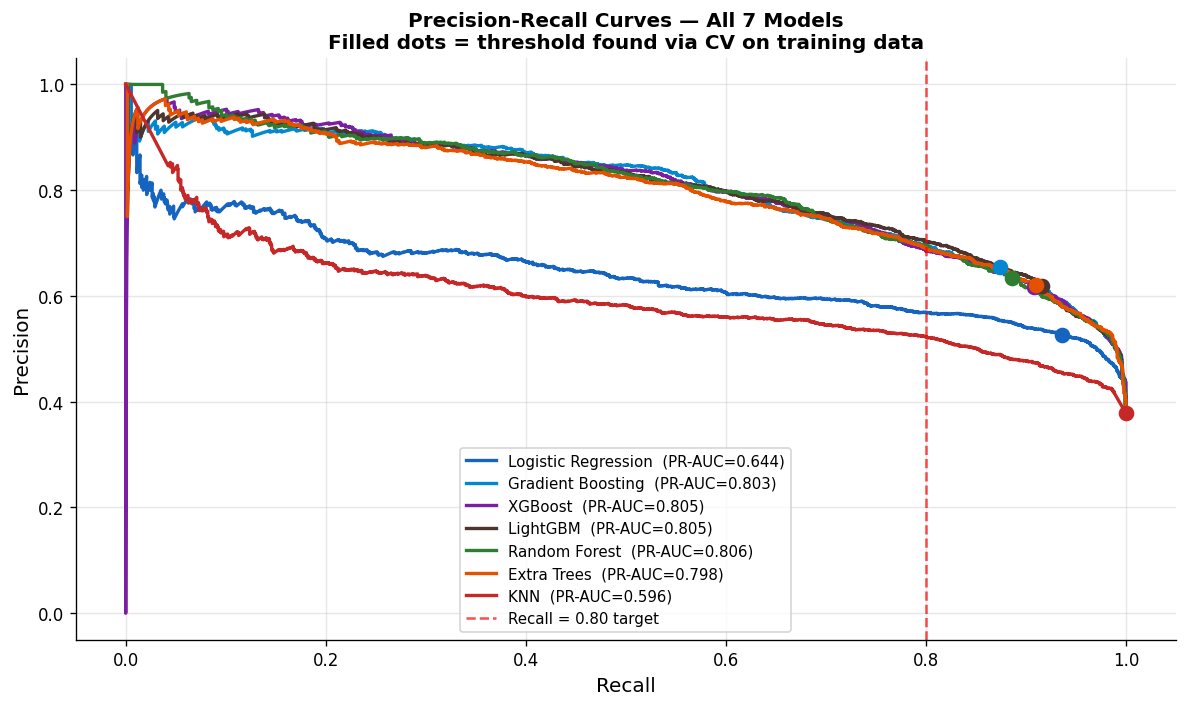

In [ ]:
# PR curves for all 7 models
# filled dots mark the CV-optimized threshold per model

fig, ax = plt.subplots(figsize=(10, 6))

colors_map = {
    'Logistic Regression': '#1565C0',
    'Gradient Boosting'  : '#0288D1',
    'XGBoost'            : '#7B1FA2',
    'LightGBM'           : '#4E342E',
    'Random Forest'      : '#2E7D32',
    'Extra Trees'        : '#E65100',
    'KNN'                : '#C62828',
}

for name in MODEL_ORDER:
    y_prob = y_probs_after[name]
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    ax.plot(rec_arr, prec_arr,
            label=f"{name}  (PR-AUC={pr_auc:.3f})",
            color=colors_map[name], lw=2)

    # mark where the CV-optimized threshold lands on each curve
    opt_thr  = opt_thresholds[name]
    y_pred_o = (y_prob >= opt_thr).astype(int)
    opt_rec  = recall_score(y_test, y_pred_o,    zero_division=0)
    opt_prec = precision_score(y_test, y_pred_o, zero_division=0)
    ax.scatter(opt_rec, opt_prec,
               color=colors_map[name], s=70, zorder=5)

ax.axvline(0.8, color='red', ls='--', lw=1.5, alpha=0.7,
           label='Recall = 0.8 target')
ax.set_xlabel('Recall',    fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All 7 Models\n'
             'Filled dots = threshold found via CV on training data',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 11. All-Model Comparison

### 11.1 Default Threshold Comparison Before & After Tuning (threshold = 0.5)

In [ ]:
rows = []
for name in MODEL_ORDER:
    b = metrics_before[name]
    a = metrics_after[name]
    rows.append({
        'Model'           : name,
        'Recall (before)' : round(b['recall'],  4),
        'F1 (before)'     : round(b['f1'],      4),
        'PR-AUC (before)' : round(b['pr_auc'],  4),
        'Recall (after)'  : round(a['recall'],  4),
        'F1 (after)'      : round(a['f1'],      4),
        'PR-AUC (after)'  : round(a['pr_auc'],  4),
        'Delta F1'        : round(a['f1'] - b['f1'], 4),
    })

df_default = (pd.DataFrame(rows)
                .sort_values('F1 (after)', ascending=False)
                .reset_index(drop=True))
df_default.index += 1
print("Default-threshold leaderboard (ranked by F1 after tuning):")
print(df_default.to_string())

Default-threshold leaderboard (ranked by F1 after tuning):
                 Model  Recall (before)  F1 (before)  PR-AUC (before)  Recall (after)  F1 (after)  PR-AUC (after)  Delta F1
1             LightGBM           0.8849       0.7360           0.7765          0.8535      0.7495          0.8045    0.0135
2    Gradient Boosting           0.8744       0.7362           0.7904          0.8651      0.7474          0.8030    0.0112
3          Extra Trees           0.9124       0.7078           0.7144          0.8744      0.7461          0.7977    0.0382
4        Random Forest           0.8530       0.7401           0.7772          0.8018      0.7436          0.8063    0.0035
5              XGBoost           0.8926       0.7368           0.7733          0.8221      0.7409          0.8053    0.0041
6  Logistic Regression           0.8739       0.6893           0.6569          0.8491      0.6771          0.6438   -0.0122
7                  KNN           0.5336       0.5517           0.5821    

Hyperparameter tuning produced modest improvements across most
models (ΔF1 < 0.005 for GB, XGB, LightGBM, RF).

The small tuning deltas confirm that feature engineering was
the primary driver of model performance in this problem.
The signal in vehicle history, incident codes, and station
rolling rates was strong enough that default parameters
captured most of it.

Tuning refined the boundary but did not influence it aggresively.

> **Note:**
> - **LR** is the linear baseline means that all tree models should beat it.
> - **KNN** is a negative control and its underperformance validates model choice.

### 11.2 Consolidated Derived Metrics Table

This is a summary at the default 0.5 threshold.

In [ ]:
rows_derived = []
for name in MODEL_ORDER:
    a = metrics_after[name]
    rows_derived.append({
        'Model'                : name,
        'TP'                   : a['tp'],
        'FP'                   : a['fp'],
        'FN'                   : a['fn'],
        'TN'                   : a['tn'],
        'Sensitivity (Recall)' : round(a['recall'],      4),
        'Specificity'          : round(a['specificity'], 4),
        'Precision'            : round(a['precision'],   4),
        'NPV'                  : round(a['npv'],         4),
        'F1'                   : round(a['f1'],          4),
        'PR-AUC'               : round(a['pr_auc'],      4),
    })

df_derived = pd.DataFrame(rows_derived)
print("Derived metrics table (default threshold 0.5):")
print()
print("  Sensitivity = TP/(TP+FN) — of all real delays, how many caught?")
print("  Specificity = TN/(TN+FP) — of all real on-times, how many correct?")
print("  PPV         = TP/(TP+FP) — of all delay alerts, how many were real?")
print("  NPV         = TN/(TN+FN) — of all 'no-delay' calls, how many right?")
print()
print(df_derived.set_index('Model').to_string())

Derived metrics table (default threshold 0.5):

  Sensitivity = TP/(TP+FN) — of all real delays, how many caught?
  Specificity = TN/(TN+FP) — of all real on-times, how many correct?
  PPV         = TP/(TP+FP) — of all delay alerts, how many were real?
  NPV         = TN/(TN+FN) — of all 'no-delay' calls, how many right?

                       TP    FP   FN    TN  Sensitivity (Recall)  Specificity  Precision     NPV      F1  PR-AUC
Model                                                                                                           
Logistic Regression  1542  1197  274  1793                0.8491       0.5997     0.5630  0.8674  0.6771  0.6438
Gradient Boosting    1571   817  245  2173                0.8651       0.7268     0.6579  0.8987  0.7474  0.8030
XGBoost              1493   721  323  2269                0.8221       0.7589     0.6743  0.8754  0.7409  0.8053
LightGBM             1550   770  266  2220                0.8535       0.7425     0.6681  0.8930  0.7495  0.804

### 11.3 Optimized Threshold Comparison



Each model is now evaluated at its own PR-curve-optimal threshold.
This is the fairest comparison because it removes the arbitrary 0.5
default from the equation.

In [ ]:
rows_opt = []
for name in MODEL_ORDER:
    y_prob   = y_probs_after[name]
    y_pred_o = y_preds_opt[name]
    m_opt    = compute_all_metrics(y_test, y_pred_o, y_prob)
    m_def    = metrics_after[name]
    rows_opt.append({
        'Model'          : name,
        'Opt Threshold'  : round(opt_thresholds[name], 3),
        'Recall'         : round(m_opt['recall'],    4),
        'Precision'      : round(m_opt['precision'], 4),
        'F1 Score'       : round(m_opt['f1'],        4),
        'PR-AUC'         : round(m_opt['pr_auc'],    4),
        'F1 gain vs 0.5' : round(m_opt['f1'] - m_def['f1'], 4),
        'Recall ≥ 0.80'  : '✓' if m_opt['recall'] >= 0.80 else '✗',
    })

df_opt = (pd.DataFrame(rows_opt)
            .sort_values('F1 Score', ascending=False)
            .reset_index(drop=True))
df_opt.index += 1
print("Optimized-threshold leaderboard:")
print(df_opt.to_string())
print("\nKey: A threshold < 0.5 implies that the model shifts toward recall while a threshold > 0.5 that the model shifts toward precision")

Optimized-threshold leaderboard:
                 Model  Opt Threshold  Recall  Precision  F1 Score  PR-AUC  F1 gain vs 0.5 Recall ≥ 0.80
1    Gradient Boosting          0.492  0.8744     0.6548    0.7489  0.8030          0.0015             ✓
2        Random Forest          0.425  0.8860     0.6340    0.7391  0.8063         -0.0045             ✓
3             LightGBM          0.420  0.9163     0.6188    0.7387  0.8045         -0.0108             ✓
4          Extra Trees          0.450  0.9097     0.6215    0.7385  0.7977         -0.0076             ✓
5              XGBoost          0.392  0.9080     0.6169    0.7347  0.8053         -0.0063             ✓
6  Logistic Regression          0.445  0.9361     0.5270    0.6743  0.6438         -0.0027             ✓
7                  KNN          0.000  1.0000     0.3779    0.5485  0.5958         -0.0073             ✓

Key: A threshold < 0.5 implies that the model shifts toward recall while a threshold > 0.5 that the model shifts toward precis

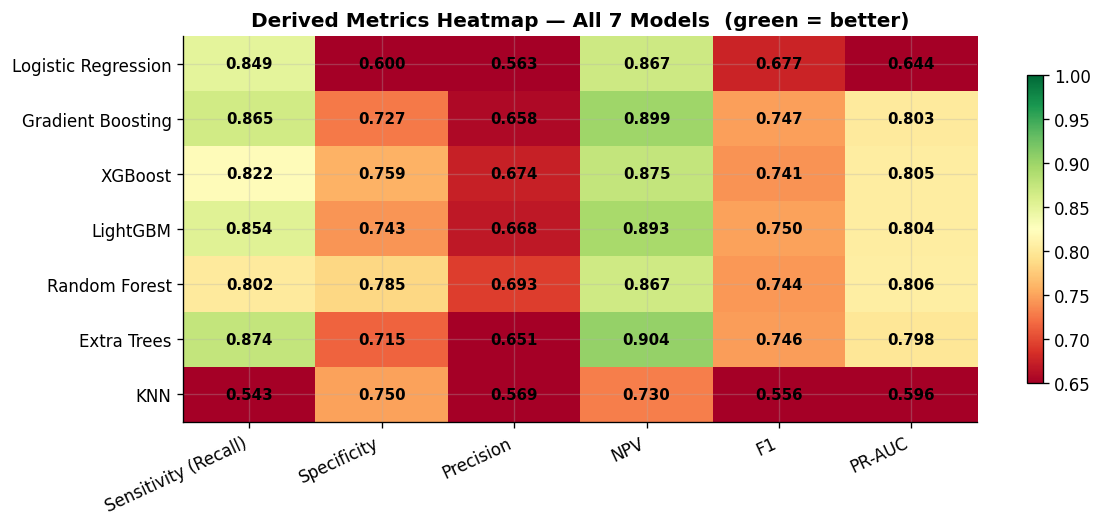

In [ ]:
# Heatmap of derived metrics — all models at a glance
metric_cols  = ['Sensitivity (Recall)', 'Specificity', 'Precision',
                'NPV', 'F1', 'PR-AUC']
heatmap_data = df_derived.set_index('Model')[metric_cols]

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', vmin=0.65, vmax=1.0, aspect='auto')

ax.set_xticks(range(len(metric_cols)))
ax.set_xticklabels(metric_cols, rotation=25, ha='right', fontsize=10)
ax.set_yticks(range(len(MODEL_ORDER)))
ax.set_yticklabels(MODEL_ORDER, fontsize=10)
ax.set_title('Derived Metrics Heatmap — All 7 Models  (green = better)',
             fontweight='bold')

for i in range(len(MODEL_ORDER)):
    for j in range(len(metric_cols)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=9, fontweight='bold', color='black')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### 11.4 Feature Importance

In [ ]:
# Models that have a meaningful importance score
IMPORTANCE_MODELS = [
    'Logistic Regression', 'Gradient Boosting', 'XGBoost',
    'LightGBM', 'Random Forest', 'Extra Trees',
]

# Normalise each model's importances to [0, 1] so they're comparable
norm_fi = {}
for name in IMPORTANCE_MODELS:
    fi = feature_imps[name].copy().fillna(0)
    fi_range = fi.max() - fi.min()
    norm_fi[name] = (fi - fi.min()) / fi_range if fi_range > 0 else fi

# Average normalised importance across all 6 models
avg_fi = pd.DataFrame(norm_fi).mean(axis=1).sort_values(ascending=False)

print("Top 20 features by average normalised importance across 6 models:")
print(avg_fi.head(20).round(4).to_string())

Top 20 features by average normalised importance across 6 models:
code_frequency                0.9268
code_encoded                  0.5539
code_MUIS                     0.4333
code_MUNCA                    0.3265
code_TUNCA                    0.2824
code_PUMEL                    0.2751
code_MUIRS                    0.2565
is_bidirectional              0.1898
station_delay_rate            0.1741
code_MUSC                     0.1559
hourly_line_delays            0.1423
hour                          0.1118
station_rolling_delay_rate    0.1059
line_rolling_delay_rate       0.1021
code_MUPAA                    0.0997
code_SUDP                     0.0957
code_SUO                      0.0951
station_incident_count        0.0887
line_time_since_last          0.0844
station_time_since_last       0.0816


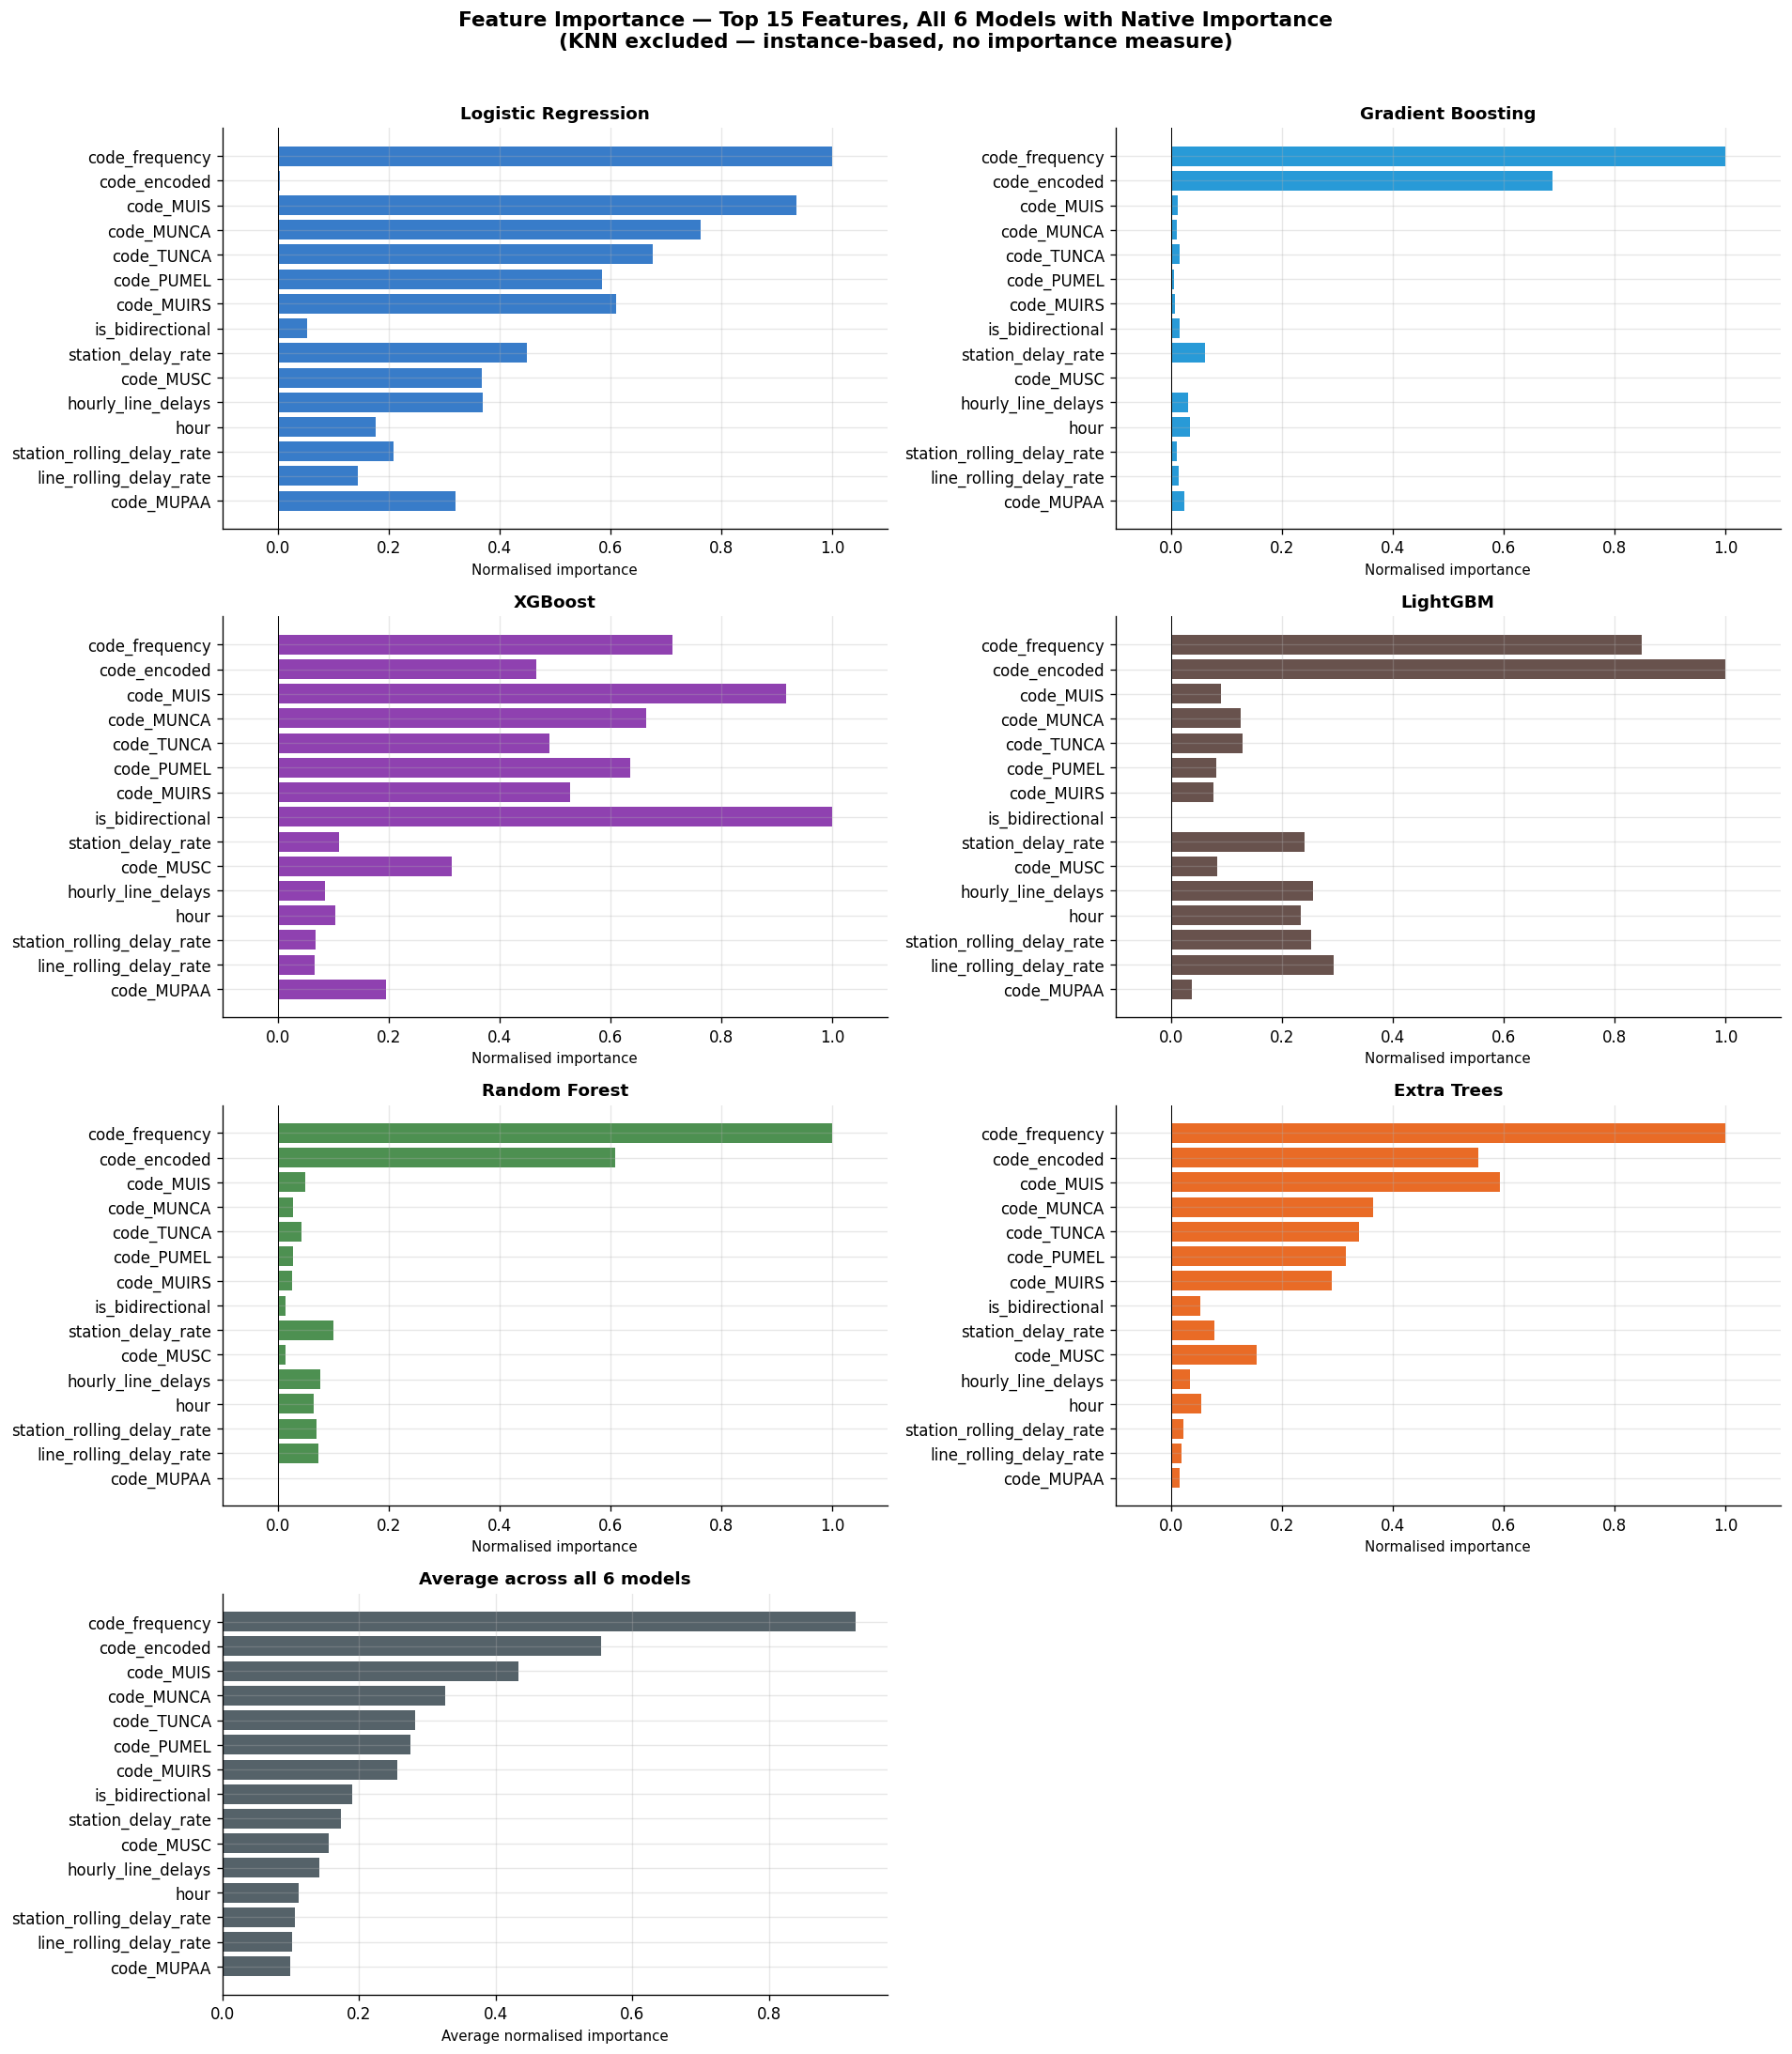

In [ ]:
# One subplot per model + average
top15 = avg_fi.head(15).index.tolist()

model_colors = {
    'Logistic Regression': '#1565C0',
    'Gradient Boosting'  : '#0288D1',
    'XGBoost'            : '#7B1FA2',
    'LightGBM'           : '#4E342E',
    'Random Forest'      : '#2E7D32',
    'Extra Trees'        : '#E65100',
}

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
flat_axes = axes.flatten()

for idx, name in enumerate(IMPORTANCE_MODELS):
    ax = flat_axes[idx]
    fi_vals = feature_imps[name][top15].fillna(0)
    fi_max  = fi_vals.abs().max()
    if fi_max > 0:
        fi_vals = fi_vals / fi_max   # normalise for display
    ax.barh(top15[::-1], fi_vals.values[::-1], color=model_colors[name], alpha=0.85)
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Normalised importance', fontsize=9)
    ax.axvline(0, color='black', lw=0.6)
    ax.set_xlim(-0.1, 1.1)

# Final subplot: cross-model average
ax = flat_axes[6]
ax.barh(top15[::-1], avg_fi[top15].values[::-1], color='#37474F', alpha=0.85)
ax.set_title('Average across all 6 models', fontweight='bold', fontsize=11)
ax.set_xlabel('Average normalised importance', fontsize=9)

flat_axes[7].set_visible(False)   # hide the empty 8th panel

fig.suptitle('Feature Importance — Top 15 Features, All 6 Models with Native Importance\n'
             '(KNN excluded — instance-based, no importance measure)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 11.5 Before vs. After Tuning Visual Summary

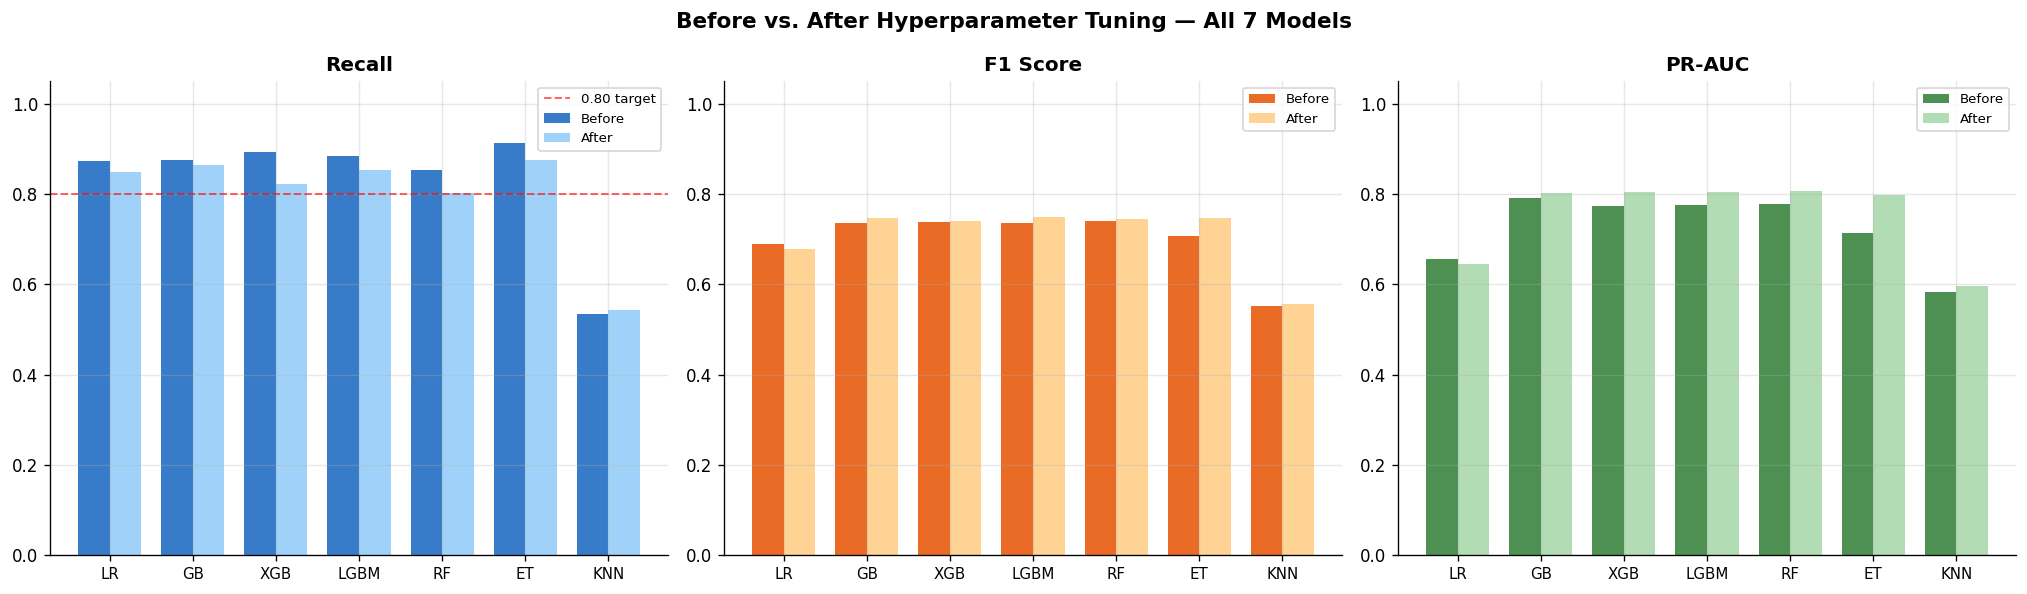

In [ ]:
MODEL_SHORT = ['LR', 'GB', 'XGB', 'LGBM', 'RF', 'ET', 'KNN']
x = np.arange(len(MODEL_ORDER))
w = 0.38

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Before vs. After Hyperparameter Tuning — All 7 Models',
             fontweight='bold', fontsize=13)

pairs = [
    ('recall',  'Recall',   '#1565C0', '#90CAF9'),
    ('f1',      'F1 Score', '#E65100', '#FFCC80'),
    ('pr_auc',  'PR-AUC',   '#2E7D32', '#A5D6A7'),
]

for ax, (key, title, c1, c2) in zip(axes, pairs):
    before_vals = [metrics_before[n][key] for n in MODEL_ORDER]
    after_vals  = [metrics_after[n][key]  for n in MODEL_ORDER]
    ax.bar(x - w/2, before_vals, w, label='Before', color=c1, alpha=0.85)
    ax.bar(x + w/2, after_vals,  w, label='After',  color=c2, alpha=0.85)
    if key == 'recall':
        ax.axhline(0.80, color='red', ls='--', lw=1.2, alpha=0.6, label='0.80 target')
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_SHORT, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 11.6 Confusion Matrix Grid

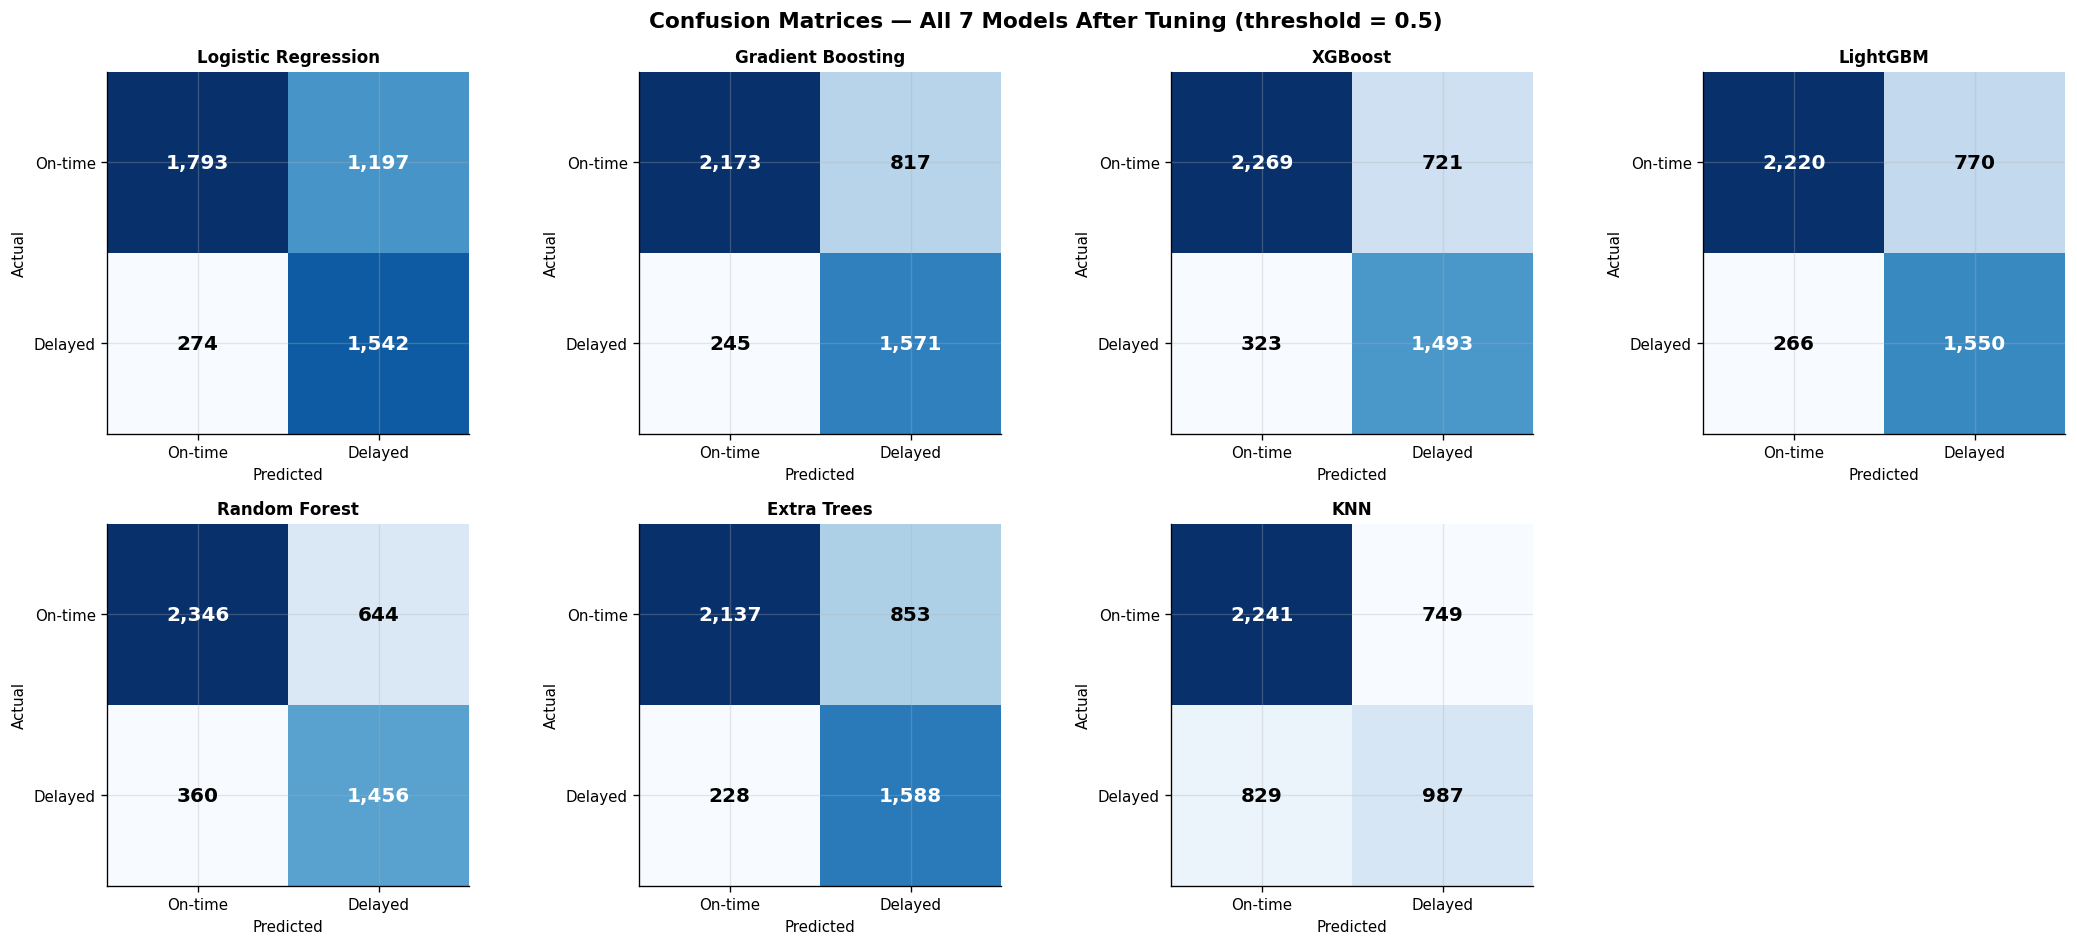

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
flat = axes.flatten()
fig.suptitle('Confusion Matrices — All 7 Models After Tuning (threshold = 0.5)',
             fontweight='bold', fontsize=13)

for i, name in enumerate(MODEL_ORDER):
    ax      = flat[i]
    cm_data = metrics_after[name]['cm']

    ax.imshow(cm_data, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['On-time', 'Delayed'], fontsize=9)
    ax.set_yticklabels(['On-time', 'Delayed'], fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('Actual',    fontsize=9)

    thresh = cm_data.max() / 2
    for r in range(2):
        for c in range(2):
            ax.text(c, r, f'{cm_data[r, c]:,}',
                    ha='center', va='center', fontsize=12, fontweight='bold',
                    color='white' if cm_data[r, c] > thresh else 'black')

flat[7].set_visible(False)
plt.tight_layout()
plt.show()